# Tag Alterations Database Analysis

## 1. Import Libraries

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import pickle
import re
pd.set_option('display.max_colwidth', None)
print("Libraries imported successfully")

Libraries imported successfully


In [2]:
analyzed_origins = 328_424_115 # more than 1 snapshot
skipped_origins = 74_425_148 # 1 snapshot or less
relevant_origins = 45_525_442 # at least 1 tag and 2 snapshots
total_tags = 3_197_620_436
total_l_tags = 1_417_510_761
total_a_tags = 1_780_109_675
unknown_branch = 819

## 2. Connect to Database and Load Data

In [3]:
df = pd.read_pickle("../data/full_2025-10_v2.pkl")

### 2.1. Skip if `pickle` used

In [3]:
conn = sqlite3.connect('../data/tags_alterations_full_2025-10_v2.db')
df = pd.read_sql_query("SELECT * FROM tag_inconsistencies", conn)

print(f"Loaded {len(df)} tag inconsistencies from database")

Loaded 15166153 tag inconsistencies from database


In [4]:
for col in ['old_snap_timestamp', 'old_rev_timestamp', 'new_snap_timestamp', 'new_rev_timestamp', 'min_delta']:
    df[col] = pd.to_datetime(df[col], unit='s', errors='coerce')


In [5]:
df['snap_year'] = df['new_snap_timestamp'].dt.year
df['rev_year'] = df['new_rev_timestamp'].dt.year
df['category'] = df['new_revision'].apply(lambda x: 'Alteration' if pd.notna(x) else 'Deletion')

In [6]:
invalid_snapshots = df[df['old_snap_timestamp'] >= df['new_snap_timestamp']]

print(f"Total inconsistencies: {len(df)}")
print(f"Cases where old_snap_timestamp > new_snap_timestamp: {len(invalid_snapshots)}")
print(f"Valid snapshot ordering: {len(df) - len(invalid_snapshots)} ({100 * (len(df) - len(invalid_snapshots)) / len(df):.2f}%)")

if len(invalid_snapshots) > 0:
    print("\nSample of invalid cases:")
    print(invalid_snapshots[['origin_url', 'tag_name', 'old_snap_timestamp', 'new_snap_timestamp']].head(10))
else:
    print("\n✓ All old_snapshot timestamps are older than their corresponding new_snapshot timestamps")

Total inconsistencies: 15166153
Cases where old_snap_timestamp > new_snap_timestamp: 1
Valid snapshot ordering: 15166152 (100.00%)

Sample of invalid cases:
                                              origin_url          tag_name  \
11005277  https://github.com/cornerstonejs/cornerstone3D  refs/tags/v2.2.3   

          old_snap_timestamp  new_snap_timestamp  
11005277 2024-11-12 18:40:57 2024-11-12 18:40:57  


In [7]:
df = df.drop(columns=['id'])

In [8]:
df['delta'] = np.where(
    (df['new_snapshot_cpt'] - df['old_snapshot_cpt']) < 2,
    0,
    (df['min_delta'] - df['old_snap_timestamp']).dt.days
)

In [9]:
def categorize_platform(origin_url):
    if pd.isna(origin_url):
        return 'Other'
    if re.match(r'^https?://[^/]*github\.com', origin_url):
        return 'GitHub'
    elif re.match(r'^https?://[^/]*gitlab\.', origin_url):
        return 'GitLab'
    elif re.match(r'^https?://android\.googlesource\.com', origin_url):
        return 'Android'
    elif re.match(r'^https?://[^/]*bitbucket\.', origin_url):
        return 'BitBucket'
    elif re.match(r'^https?://[^/]*codeberg\.', origin_url):
        return 'Codeberg'
    elif re.match(r'^https?://[^/]*git\.sr\.ht', origin_url):
        return 'SourceHut'
    else:
        return 'Other'

df['platform'] = df['origin_url'].apply(categorize_platform)

In [10]:
df.sample(5)

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,...,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform
9081438,https://gitlab.softwareheritage.org/swh/devel/swh-search.git,refs/tags/debian/upstream/0.2.3,annotated,swh:1:snp:c669bf5733c6b9f1dfa3ed225092d5cd4d76791b,0,2023-04-03 15:31:00,swh:1:rev:adef770f0a627817ed77f3d15171a329bfe6d004,2020-09-25 10:53:11,swh:1:dir:0a32c46bac157986f59045abc457d92bc2a8062e,swh:1:snp:ced33c3d18e0e90b0247fbec2f337abade017f9f,...,2025-03-27 13:58:28,NaN,NaT,NaN,2024-12-26 11:46:43,2025,NaN,Deletion,632,GitLab
14272315,https://github.com/jthiltges/htcondor,refs/tags/BUILD-V7_0-branch-2008-8-14,lightweight,swh:1:snp:cc7cbff946ca44630a83212ae7ce481d42eafaf3,0,2017-12-14 04:43:20,swh:1:rev:18da031ee18884106ed64eaa108990ff505591d1,2008-08-13 21:56:57,swh:1:dir:ffd20c9e0245f2953f256efdcccc4694fffba727,swh:1:snp:258f5834da82843c0eaac3ffaadd1d176a0bff1c,...,2025-02-16 23:56:16,NaN,NaT,NaN,2017-12-14 04:43:20,2025,NaN,Deletion,0,GitHub
8515947,https://github.com/betterpony/rt-thread,refs/tags/v3.0.4,lightweight,swh:1:snp:b498189b18e93d5b187dce8dd9107b56bae4d8cd,0,2020-07-19 16:02:36,swh:1:rev:37d8cc4ff2435ad2eeb6cae44a2d602b9fa5e613,2018-05-31 09:47:25,swh:1:dir:6a5bd55f57a76aebf35ad51458db86d668eeef72,swh:1:snp:2306e86cb601e301fcb8f3800ba6f1d41afbe939,...,2023-08-08 16:37:18,NaN,NaT,NaN,2023-04-28 00:20:25,2023,NaN,Deletion,1012,GitHub
1318090,https://github.com/Lekanich/intellij-community,refs/tags/pycharm/133.488,annotated,swh:1:snp:2e1c2d7de1c09c1be150bc188a04d91d55cc5171,0,2017-06-17 20:21:49,swh:1:rev:1e2b2ce812734f4f82365efda1b63968ad26a23b,2013-12-31 12:06:34,swh:1:dir:c84d6864a0bcda12db1adb63bad7e66915fe10ae,swh:1:snp:aae71a6aff5cc22f49249bba07ff57d6851df438,...,2023-12-21 02:51:42,NaN,NaT,NaN,2019-07-07 01:41:39,2023,NaN,Deletion,749,GitHub
6869098,https://github.com/StreamLayer/sdk-ios,refs/tags/v0.0.54,lightweight,swh:1:snp:63c953b1d29440d94ad131714fb67860365dfc81,11,2022-05-19 02:12:14,swh:1:rev:b3be29f39854260862de9ebba25cf12b609d4760,2022-03-25 21:27:00,swh:1:dir:30c443e6887106a46a1a03263d8229fc4af30faf,swh:1:snp:50da9fae107e4e9936903db19dfb7e200e048dc0,...,2022-09-19 06:16:15,NaN,NaT,NaN,2022-09-01 23:59:24,2022,NaN,Deletion,105,GitHub


In [4]:
stars = pd.read_pickle("/home/infres/rapaport/datasets/github-stars/github-stars.pkl")

In [5]:
stars.head(3)

,origin,stars
0,"""https://github.com/Jatin-8898/flappy-bird-react""",2
1,"""https://github.com/MayorgaAbogados/MM_20190730_MainWebsite_App""",0
2,"""https://github.com/stewartcintra/omnistack9_app""",0


In [6]:
stars['origin'] = stars['origin'].str.strip('"')

In [7]:
stars.head(3)

,origin,stars
0,https://github.com/Jatin-8898/flappy-bird-react,2
1,https://github.com/MayorgaAbogados/MM_20190730_MainWebsite_App,0
2,https://github.com/stewartcintra/omnistack9_app,0


In [ ]:
print(f"Stars before dedup: {len(stars)}")
print(f"Unique origins in stars: {stars['origin'].nunique()}")
stars = stars.drop_duplicates(subset='origin')
print(f"Stars after dedup on 'origin': {len(stars)}")

Stars before dedup: 278827680


In [10]:
# Merge stars data with df: match df's 'origin_url' with stars' 'origin'
df = df.merge(stars[['origin', 'stars']], 
              left_on='origin_url', 
              right_on='origin', 
              how='left')

print(f"DataFrame shape after merge: {df.shape}")
print(f"Number of rows with stars data: {df['stars'].notna().sum()}")
print(f"Number of rows without stars data (null): {df['stars'].isna().sum()}")

DataFrame shape after merge: (56234963, 23)
Number of rows with stars data: 53450404
Number of rows without stars data (null): 2784559


In [11]:
print(len(df))

56234963


In [12]:
df.head(5)

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,...,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,origin,stars
0,https://github.com/elevenlee/oop_generics,refs/tags/v1.0,lightweight,swh:1:snp:589750d264ea6ba72cd290d154b089ce79c20b14,0,2015-08-05 00:56:29,swh:1:rev:16f2c36c23dc1e432a183f2575be1e2b4d654ca9,2012-12-29 07:00:19,swh:1:dir:e482b7c2c58ab76031e45dd163c159e1a46b70a2,swh:1:snp:e613bc07696f35d8c1d341bd9928a313d3a705ac,...,NaT,NaN,2015-08-05 00:56:29,2016,NaN,Deletion,0,GitHub,https://github.com/elevenlee/oop_generics,0.0
1,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.0.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:29e7fce9fc88a55bdafb507f6506bd6f153260b0,2020-04-27 03:35:14,swh:1:dir:c612010c922cea11ecdfa384db474123a0225d73,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,https://github.com/innovation-cat/innovation-cat.github.io,0.0
2,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.0.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:29e7fce9fc88a55bdafb507f6506bd6f153260b0,2020-04-27 03:35:14,swh:1:dir:c612010c922cea11ecdfa384db474123a0225d73,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,https://github.com/innovation-cat/innovation-cat.github.io,1.0
3,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.2.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:16a7fefff1f1fb674d1ed0328099a8d6ac0d38bb,2020-04-27 19:31:38,swh:1:dir:3727b13bc24dad71024adebc98eb17a2b9310d35,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,https://github.com/innovation-cat/innovation-cat.github.io,0.0
4,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.2.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:16a7fefff1f1fb674d1ed0328099a8d6ac0d38bb,2020-04-27 19:31:38,swh:1:dir:3727b13bc24dad71024adebc98eb17a2b9310d35,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,https://github.com/innovation-cat/innovation-cat.github.io,1.0


In [13]:
df[df['stars'].notnull()]

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,...,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,origin,stars
0,https://github.com/elevenlee/oop_generics,refs/tags/v1.0,lightweight,swh:1:snp:589750d264ea6ba72cd290d154b089ce79c20b14,0,2015-08-05 00:56:29,swh:1:rev:16f2c36c23dc1e432a183f2575be1e2b4d654ca9,2012-12-29 07:00:19,swh:1:dir:e482b7c2c58ab76031e45dd163c159e1a46b70a2,swh:1:snp:e613bc07696f35d8c1d341bd9928a313d3a705ac,...,NaT,NaN,2015-08-05 00:56:29,2016,NaN,Deletion,0,GitHub,https://github.com/elevenlee/oop_generics,0.0
1,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.0.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:29e7fce9fc88a55bdafb507f6506bd6f153260b0,2020-04-27 03:35:14,swh:1:dir:c612010c922cea11ecdfa384db474123a0225d73,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,https://github.com/innovation-cat/innovation-cat.github.io,0.0
2,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.0.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:29e7fce9fc88a55bdafb507f6506bd6f153260b0,2020-04-27 03:35:14,swh:1:dir:c612010c922cea11ecdfa384db474123a0225d73,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,https://github.com/innovation-cat/innovation-cat.github.io,1.0
3,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.2.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:16a7fefff1f1fb674d1ed0328099a8d6ac0d38bb,2020-04-27 19:31:38,swh:1:dir:3727b13bc24dad71024adebc98eb17a2b9310d35,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,https://github.com/innovation-cat/innovation-cat.github.io,0.0
4,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.2.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:16a7fefff1f1fb674d1ed0328099a8d6ac0d38bb,2020-04-27 19:31:38,swh:1:dir:3727b13bc24dad71024adebc98eb17a2b9310d35,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,https://github.com/innovation-cat/innovation-cat.github.io,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56234955,https://github.com/SolarFramework/Sample-Slam,refs/tags/SLAM/MultiThread/0.7.0/Release,lightweight,swh:1:snp:c2774262241da1d89d3aa0578dd2c913a84fab77,2,2020-03-18 09:27:04,swh:1:rev:dc351a678abc5fb73efcfcf550e58784fa5682a2,2019-07-29 14:29:00,swh:1:dir:0b176d3cdd4da2e4c75c599500bbda5f935d0207,swh:1:snp:ebf412e020d7f130d132fe0295e0a2d700a8fac5,...,NaT,NaN,2020-03-18 09:27:04,2021,NaN,Deletion,0,GitHub,https://github.com/SolarFramework/Sample-Slam,1.0
56234956,https://github.com/SolarFramework/Sample-Slam,refs/tags/SolARPipeline_SLAM/0.9.1/android,lightweight,swh:1:snp:4a34b88a1266ea49f7b1f0504f01d72de764ec8c,4,2021-07-17 13:36:17,swh:1:rev:48380bb57d9e84bead558a0e953f23779e149696,2021-07-09 09:28:09,swh:1:dir:56d915c61856d34ee4556d8b8035283a5d32282b,swh:1:snp:6f291f650d0a26a7825076fc7d1ed55bcfcb7965,...,2021-07-21 07:07:12,swh:1:dir:0a14456619b66f1dc59fc6d52b82ba9b192f8499,2021-07-17 13:36:17,2021,2021.0,Alteration,0,GitHub,https://github.com/SolarFramework/Sample-Slam,0.0
56234957,https://github.com/SolarFramework/Sample-Slam,refs/tags/SolARPipeline_SLAM/0.9.1/android,lightweight,swh:1:snp:4a34b88a1266ea49f7b1f0504f01d72de764ec8c,4,2021-07-17 13:36:17,swh:1:rev:48380bb57d9e84bead558a0e953f23779e149696,2021-07-09 09:28:09,swh:1:dir:56d915c61856d34ee4556d8b8035283a5d32282b,swh:1:snp:6f291f650d0a26a7825076fc7d1ed55bcfcb7965,...,2021-07-21 07:07:12,swh:1:dir:0a14456619b66f1dc59fc6d52b82ba9b192f8499,20

In [ ]:
with open('../data/full_2025-10_v3.pkl', 'wb') as f:
    pickle.dump(df, f) 

## 3. Explore the DataFrame

In [12]:
print("DataFrame shape:", df.shape)
df.head()

DataFrame shape: (15166153, 21)


,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,...,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform
0,https://github.com/elevenlee/oop_generics,refs/tags/v1.0,lightweight,swh:1:snp:589750d264ea6ba72cd290d154b089ce79c20b14,0,2015-08-05 00:56:29,swh:1:rev:16f2c36c23dc1e432a183f2575be1e2b4d654ca9,2012-12-29 07:00:19,swh:1:dir:e482b7c2c58ab76031e45dd163c159e1a46b70a2,swh:1:snp:e613bc07696f35d8c1d341bd9928a313d3a705ac,...,2016-03-14 02:41:49,NaN,NaT,NaN,2015-08-05 00:56:29,2016,NaN,Deletion,0,GitHub
1,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.0.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:29e7fce9fc88a55bdafb507f6506bd6f153260b0,2020-04-27 03:35:14,swh:1:dir:c612010c922cea11ecdfa384db474123a0225d73,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,2022-03-12 17:36:22,NaN,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub
2,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.2.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:16a7fefff1f1fb674d1ed0328099a8d6ac0d38bb,2020-04-27 19:31:38,swh:1:dir:3727b13bc24dad71024adebc98eb17a2b9310d35,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,2022-03-12 17:36:22,NaN,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub
3,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/3.0.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:85401c9f014ff7d8950b1930e732b73fd6d08043,2020-05-07 07:24:36,swh:1:dir:65029e9180c14f7e3c5d0d1d3cf0b9b697b5e60e,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,2022-03-12 17:36:22,NaN,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub
4,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.3.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:6fa41ccd9ece1292f0df3554e0c5f6680c82e818,2020-04-29 08:42:15,swh:1:dir:1edad0e47774c0fb05657616f6d8a4210cbcacb0,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,...,2022-03-12 17:36:22,NaN,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub


## 4. Queries

In [7]:
tag_deletions = df[df['new_revision'].isnull()]
tag_moves = df[df['new_revision'].notnull()]
tag_annotated = df[df['type'] == "annotated"]
tag_lightweight = df[df['type'] == "lightweight"]

print(f"Tag Moves: {len(tag_moves):_}")
print(f"Tag Deletions: {len(tag_deletions):_}")
print(f"Total: {len(df):_}")
print(f"\nTag annotated: {len(tag_annotated):_}")
print(f"Tag lightweight: {len(tag_lightweight):_}")

Tag Moves: 613_087
Tag Deletions: 14_553_066
Total: 15_166_153

Tag annotated: 4_410_901
Tag lightweight: 10_755_252


In [8]:
tag_moves_a = tag_moves[tag_moves['type'] == "annotated"]
tag_moves_l = tag_moves[tag_moves['type'] == "lightweight"]
tag_deletions_a = tag_deletions[tag_deletions['type'] == "annotated"]
tag_deletions_l = tag_deletions[tag_deletions['type'] == "lightweight"]
print("======= Annotated =======")
print(f"Tag Moves: {len(tag_moves_a):_}")
print(f"Tag Deletions: {len(tag_deletions_a):_}")
print("======= Lightweight =======")
print(f"Tag Moves: {len(tag_moves_l):_}")
print(f"Tag Deletions: {len(tag_deletions_l):_}")

======= Annotated =======
Tag Moves: 184_888
Tag Deletions: 4_226_013
======= Lightweight =======
Tag Moves: 428_199
Tag Deletions: 10_327_053


In [15]:
unique_origins = df['origin_url'].drop_duplicates().reset_index(drop=True)
unique_a_tag = tag_annotated[['origin_url', 'tag_name']].drop_duplicates().reset_index(drop=True)
unique_l_tag = tag_lightweight[['origin_url', 'tag_name']].drop_duplicates().reset_index(drop=True)

In [16]:
print(f"Origin with an altered tag: {(len(unique_origins)/relevant_origins)*100:.2f}%")
print(f"Altered annotated tag: {(len(unique_a_tag)/total_a_tags)*100:.2f}%")
print(f"Altered lightweight tag: {(len(unique_l_tag)/total_l_tags)*100:.2f}%")

Origin with an altered tag: 1.24%
Altered annotated tag: 0.24%
Altered lightweight tag: 0.75%


In [23]:
df[['origin_url', 'tag_name']].drop_duplicates().reset_index(drop=True)

,origin_url,tag_name
0,https://github.com/elevenlee/oop_generics,refs/tags/v1.0
1,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.0.0
2,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.2.0
3,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/3.0.0
4,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.3.0
...,...,...
14821178,https://github.com/SolarFramework/Sample-Slam,refs/tags/SLAM/MultiThread/0.7.0/Release
14821179,https://github.com/SolarFramework/Sample-Slam,refs/tags/SolARPipeline_SLAM/0.9.1/android
14821180,https://github.com/CIRB/cirb.urbis,refs/tags/1.1
14821181,https://github.com/CIRB/cirb.urbis,refs/tags/1.0


In [24]:
df['origin_url'].drop_duplicates().reset_index(drop=True)

0                          https://github.com/elevenlee/oop_generics
1         https://github.com/innovation-cat/innovation-cat.github.io
2                    https://github.com/frozenbonito/vscode-textlint
3                             https://github.com/edgarwang/maze-game
4                    https://github.com/raphaa/cmsplugin-htmlsitemap
                                     ...                            
565215             https://github.com/XianwuXue-NOAA/global-workflow
565216                         https://github.com/liangrui1988/hello
565217                               https://github.com/sullis/delta
565218                 https://github.com/SolarFramework/Sample-Slam
565219                            https://github.com/CIRB/cirb.urbis
Name: origin_url, Length: 565220, dtype: str

In [25]:
# Find origins with most tag inconsistencies
origins_with_most_issues = df.groupby('origin_url').size().sort_values(ascending=False)
print("Top 10 origins with most tag inconsistencies:")
origins_with_most_issues.head(10)

Top 10 origins with most tag inconsistencies:


origin_url
https://github.com/TencentCloud/tencentcloud-sdk-go    178928
https://github.com/JetBrains/intellij-community         91540
https://github.com/jesley-sun/intellij-community        67169
https://github.com/cms-sw/cmsdist                       66307
https://github.com/netp4ss/intellij-community           63932
https://github.com/BorzdeG/intellij-community           58003
https://github.com/cms-sw/cmssw                         56605
https://github.com/mallowigi/intellij-community         56408
https://github.com/apixandru/intellij-community         53041
https://github.com/rememberber/intellij-community       49106
dtype: int64

In [26]:
tag_moves[['origin_url', 'tag_name', 'old_snapshot', 'new_snapshot', 'old_snap_timestamp', 'new_snap_timestamp', 'old_rev_timestamp', 'new_rev_timestamp', 'type']].head()

,origin_url,tag_name,old_snapshot,new_snapshot,old_snap_timestamp,new_snap_timestamp,old_rev_timestamp,new_rev_timestamp,type
150,https://github.com/danielbarela/mage-server,refs/tags/5.2.1,swh:1:snp:66cd360e06815f5e39e9281d29df5ec96e2ebeb2,swh:1:snp:54218774871910936eb3666aa4cc87947a8d4b23,2018-10-27 02:37:45,2021-02-13 20:26:14,2018-03-13 14:46:58,2018-10-25 17:25:46,lightweight
152,https://github.com/danielbarela/mage-server,refs/tags/5.2.3,swh:1:snp:66cd360e06815f5e39e9281d29df5ec96e2ebeb2,swh:1:snp:54218774871910936eb3666aa4cc87947a8d4b23,2018-10-27 02:37:45,2021-02-13 20:26:14,2018-03-13 15:04:11,2018-12-07 18:39:34,lightweight
157,https://github.com/danielbarela/mage-server,refs/tags/5.2.5,swh:1:snp:66cd360e06815f5e39e9281d29df5ec96e2ebeb2,swh:1:snp:54218774871910936eb3666aa4cc87947a8d4b23,2018-10-27 02:37:45,2021-02-13 20:26:14,2018-03-13 15:38:10,2019-03-13 18:21:49,lightweight
158,https://github.com/danielbarela/mage-server,refs/tags/5.2.4,swh:1:snp:66cd360e06815f5e39e9281d29df5ec96e2ebeb2,swh:1:snp:54218774871910936eb3666aa4cc87947a8d4b23,2018-10-27 02:37:45,2021-02-13 20:26:14,2018-03-13 15:34:05,2019-01-14 15:51:22,lightweight
162,https://github.com/danielbarela/mage-server,refs/tags/5.2.6,swh:1:snp:66cd360e06815f5e39e9281d29df5ec96e2ebeb2,swh:1:snp:54218774871910936eb3666aa4cc87947a8d4b23,2018-10-27 02:37:45,2021-02-13 20:26:14,2018-03-13 15:48:51,2019-04-11 21:19:38,lightweight


In [17]:
print(df['platform'].value_counts())

platform
GitHub       14650832
GitLab         378996
Other          124350
BitBucket       11391
Codeberg          441
Android            78
SourceHut          65
Name: count, dtype: int64


In [29]:
github_with_most_issues = github.groupby('origin_url').size().sort_values(ascending=False)
gitlab_with_most_issues = gitlab.groupby('origin_url').size().sort_values(ascending=False)
android_with_most_issues = android.groupby('origin_url').size().sort_values(ascending=False)
bitbucket_with_most_issues = bitbucket.groupby('origin_url').size().sort_values(ascending=False)
codeberg_with_most_issues = codeberg.groupby('origin_url').size().sort_values(ascending=False)
print(f"GitHub most inconsistencies:\n", github_with_most_issues.head(2))
print(f"Gitlab most inconsistencies:\n", gitlab_with_most_issues.head(2))
print(f"Android most inconsistencies:\n", android_with_most_issues.head(2))
print(f"Bitbucket most inconsistencies:\n", bitbucket_with_most_issues.head(2))
print(f"Codeberg most inconsistencies:\n", codeberg_with_most_issues.head(2))

GitHub most inconsistencies:
 origin_url
https://github.com/TencentCloud/tencentcloud-sdk-go    178928
https://github.com/JetBrains/intellij-community         91540
dtype: int64
Gitlab most inconsistencies:
 origin_url
https://gitlab.cern.ch/dta/athena.git        16611
https://gitlab.cern.ch/yuxuanz/athena.git    12093
dtype: int64
Android most inconsistencies:
 origin_url
https://android.googlesource.com/platform/external/jetbrains/JetBrainsRuntime    71
https://android.googlesource.com/platform/superproject                            4
dtype: int64
Bitbucket most inconsistencies:
 origin_url
https://bitbucket.org/coyoterd/web-apps.git      3312
https://bitbucket.org/apisnetworks/apnscp.git     960
dtype: int64
Codeberg most inconsistencies:
 origin_url
https://codeberg.org/Codeberg/gitea.git                                  116
https://codeberg.org/ungoogled-software/ungoogled-chromium-debian.git    100
dtype: int64


In [19]:
# Inconsistencies where new_root_dir equals old_root_dir
same_root_dir = df[df['new_root_dir'] == df['old_root_dir']]
print(f"Alterations where new_root_dir = old_root_dir: {len(same_root_dir):_}")
same_root_dir.head()

Alterations where new_root_dir = old_root_dir: 192_923


,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,...,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform
680,https://github.com/ultramega/elementary,refs/tags/0.1.7,lightweight,swh:1:snp:ef50023f13e286d2125b382f3d8703a02e475b7a,0,2015-07-31 13:43:42,swh:1:rev:b2678ef5d0c9825ab73f39ecf6912b79033e4a2a,2015-06-08 19:20:44,swh:1:dir:7837ec2844a71852f154187eb13c5d0b49f04e7e,swh:1:snp:cdafe0a72d7e995a4530a71fc8acba7e6a7e4287,...,2016-03-10 15:39:16,swh:1:rev:ef7c016f67292f1ad3fb680ec68c0ee0845569eb,2015-06-08 19:20:44,swh:1:dir:7837ec2844a71852f154187eb13c5d0b49f04e7e,2015-07-31 13:43:42,2016,2015.0,Alteration,0,GitHub
885,https://github.com/Tangerine-Community/Tangerine,refs/tags/v3.32.1,lightweight,swh:1:snp:02cc04768fd6ae4f2851203c2bd7088ff055f85e,95,2025-05-17 09:32:41,swh:1:rev:e9017b77c5ddc59e9070c29b2074695b2be139ef,2025-05-14 14:15:37,swh:1:dir:90507ddaf84a4d9dc8ac5d1e2bdcae0f461c63fe,swh:1:snp:79511cf10994da622273d4eb8a841abbc2d196be,...,2025-05-28 18:46:14,swh:1:rev:fa6fa631b577d1b9071f452050987fd7b3b6fd81,2025-05-19 15:14:09,swh:1:dir:90507ddaf84a4d9dc8ac5d1e2bdcae0f461c63fe,2025-05-17 09:32:41,2025,2025.0,Alteration,0,GitHub
1230,https://github.com/lugia-kun/tlpdb2spec,refs/tags/2019-5m,lightweight,swh:1:snp:ca16a61b33bdd5d7a41add1c79d2e295184d962d,14,2020-01-23 16:33:14,swh:1:rev:0dbd638b2c245bf8d0d07d235372bbebdfbb72da,2019-08-24 15:22:24,swh:1:dir:c059a0ccefa5782ff67cd7272c575ce194670167,swh:1:snp:5427ff86b4f42b611b168a09bbd614fa185aad23,...,2020-04-06 06:51:05,swh:1:rev:3e68209328b6de0871e3b6d916f8e8f511acd102,2020-03-12 11:53:47,swh:1:dir:c059a0ccefa5782ff67cd7272c575ce194670167,2020-01-23 16:33:14,2020,2020.0,Alteration,0,GitHub
1231,https://github.com/lugia-kun/tlpdb2spec,refs/tags/2019-1m,lightweight,swh:1:snp:655c62aa91e7dfa434cbdb6a3f5faade2324c780,13,2019-08-08 02:38:41,swh:1:rev:edfda9a6e8878560ca6effaed3523816a6beaf7b,2019-07-14 04:25:25,swh:1:dir:a1eab72d43d2d4b717e243b39b78c4f669797a67,swh:1:snp:5427ff86b4f42b611b168a09bbd614fa185aad23,...,2020-04-06 06:51:05,swh:1:rev:9553de174a41c0d3c515c04b2acd265a1489e2bc,2020-03-12 11:53:47,swh:1:dir:a1eab72d43d2d4b717e243b39b78c4f669797a67,2020-01-23 16:33:14,2020,2020.0,Alteration,168,GitHub
1232,https://github.com/lugia-kun/tlpdb2spec,refs/tags/2019-2m,lightweight,swh:1:snp:655c62aa91e7dfa434cbdb6a3f5faade2324c780,13,2019-08-08 02:38:41,swh:1:rev:1cf9abb9fb8d5f78e3a2bb1634b618f202761325,2019-07-19 12:02:12,swh:1:dir:1a70d2fecccfe2c76e0b0832a0d5db2bbcf463d0,swh:1:snp:5427ff86b4f42b611b168a09bbd614fa185aad23,...,2020-04-06 06:51:05,swh:1:rev:57be0ecd9cf6491bdd17c939334303619917fa6f,2020-03-12 11:53:47,swh:1:dir:1a70d2fecccfe2c76e0b0832a0d5db2bbcf463d0,2020-01-23 16:33:14,2020,2020.0,Alteration,168,GitHub


In [38]:
snapshot_delta_diversity = df.groupby(['origin_url', 'new_snapshot']).agg({
    'delta': lambda x: x.nunique(),  # number of unique delta values
    'tag_name': 'count'  # total alterations in this snapshot
}).reset_index()
snapshot_delta_diversity.columns = ['origin_url', 'new_snapshot', 'unique_deltas', 'alteration_count']

top_diverse_snapshots = snapshot_delta_diversity.sort_values('unique_deltas', ascending=False).head(10)

print("Top 10 repositories with most different delta values in a single snapshot:")
print("=" * 100)
for idx, row in top_diverse_snapshots.iterrows():
    print(f"\nRepo: {row['origin_url']}")
    print(f"  Snapshot: {row['new_snapshot'][:16]}...")
    print(f"  Unique Deltas: {row['unique_deltas']}")
    print(f"  Total Alterations: {row['alteration_count']}")

print("\n" + "=" * 100)
top_diverse_snapshots

Top 10 repositories with most different delta values in a single snapshot:

Repo: https://gitlab.freedesktop.org/gfx-ci/igt-ci-tags.git
  Snapshot: swh:1:snp:856ce8...
  Unique Deltas: 135
  Total Alterations: 5643

Repo: https://github.com/LibreDWG/libredwg
  Snapshot: swh:1:snp:21f622...
  Unique Deltas: 126
  Total Alterations: 1194

Repo: https://github.com/Azure/azure-rest-api-specs
  Snapshot: swh:1:snp:960d1a...
  Unique Deltas: 108
  Total Alterations: 1656

Repo: https://github.com/calculatelinux/calculate
  Snapshot: swh:1:snp:49447f...
  Unique Deltas: 105
  Total Alterations: 3770

Repo: https://github.com/patternfly/patternfly-react
  Snapshot: swh:1:snp:57b27f...
  Unique Deltas: 95
  Total Alterations: 6929

Repo: https://github.com/TencentCloud/tencentcloud-sdk-go
  Snapshot: swh:1:snp:abfa24...
  Unique Deltas: 92
  Total Alterations: 178346

Repo: https://github.com/v2fly/domain-list-community
  Snapshot: swh:1:snp:922767...
  Unique Deltas: 78
  Total Alterations: 21

,origin_url,new_snapshot,unique_deltas,alteration_count
699534,https://gitlab.freedesktop.org/gfx-ci/igt-ci-tags.git,swh:1:snp:856ce8c47a7fb8ee93ebdb6d9a2fa3148509c3a0,135,5643
79050,https://github.com/LibreDWG/libredwg,swh:1:snp:21f6227a62fb95ae8b05bb367dd05e377aee9492,126,1194
22517,https://github.com/Azure/azure-rest-api-specs,swh:1:snp:960d1ae63113e650e692f4872be167849904d102,108,1656
211071,https://github.com/calculatelinux/calculate,swh:1:snp:49447fb57c64fdff791d176f0281dffd7888a7c2,105,3770
511318,https://github.com/patternfly/patternfly-react,swh:1:snp:57b27f100b8721ea43d15e67e5050eee11a7d5fb,95,6929
128721,https://github.com/TencentCloud/tencentcloud-sdk-go,swh:1:snp:abfa2429557192d2f6c43ce20c5c267d5d3ce50c,92,178346
641704,https://github.com/v2fly/domain-list-community,swh:1:snp:92276787a15cfbb9790486d5ebeffc35f1f873aa,78,2162
206778,https://github.com/bryanedds/Nu,swh:1:snp:7194238897359e3949f8753383f34213a364f99e,78,363
316138,https://github.com/gemini-testing/hermione,swh:1:snp:3056f3b8aeb6b4dbe4fc2c6c5dc4de99470ec356,75,390
22513,https://github.com/Azure/azure-rest-api-specs,swh:1:snp:8a29f61741ff4d601db71413c95505a265d70d75,75,423


In [41]:
top_repo = top_diverse_snapshots.iloc[0]
top_repo_url = top_repo['origin_url']
top_snapshot = top_repo['new_snapshot']

print(f"Detailed analysis of top repository:")
print(f"Repository: {top_repo_url}")
print(f"Snapshot: {top_snapshot}")
print("\n" + "=" * 100)

# Get all alterations for this specific snapshot
snapshot_details = df[(df['origin_url'] == top_repo_url) & 
                        (df['new_snapshot'] == top_snapshot)].sort_values('delta')

print(f"\n\nDelta value distribution ({len(snapshot_details)} total alterations):")
delta_dist = snapshot_details['delta'].value_counts().sort_index()
print(delta_dist)

print(f"\n\nSample alterations showing different delta values:")
print("=" * 100)
# Show 1-2 examples from each unique delta value
sample_rows = []
for delta_val in sorted(snapshot_details['delta'].unique()):
    delta_samples = snapshot_details[snapshot_details['delta'] == delta_val].head(2)
    sample_rows.append(delta_samples)

sample_df = pd.concat(sample_rows)
print(sample_df[['tag_name', 'delta', 'old_snapshot', 'old_snap_timestamp', 
                 'new_snap_timestamp', 'category', 'type']].to_string())

Detailed analysis of top repository:
Repository: https://gitlab.freedesktop.org/gfx-ci/igt-ci-tags.git
Snapshot: swh:1:snp:856ce8c47a7fb8ee93ebdb6d9a2fa3148509c3a0



Delta value distribution (5643 total alterations):
delta
0       510
83      466
173     311
270     291
361       7
       ... 
1089     17
1093     28
1101     70
1117    137
1150     24
Name: count, Length: 135, dtype: int64


Sample alterations showing different delta values:
                              tag_name  delta                                        old_snapshot  old_snap_timestamp  new_snap_timestamp  category         type
1793933     refs/tags/intel/IGTPW_7520      0  swh:1:snp:957b719040f8958f2fb20bc22d8f6d14c55e756f 2022-08-22 12:47:46 2022-11-25 13:12:58  Deletion  lightweight
1795796     refs/tags/intel/IGTPW_7267      0  swh:1:snp:957b719040f8958f2fb20bc22d8f6d14c55e756f 2022-08-22 12:47:46 2022-11-25 13:12:58  Deletion  lightweight
1799207     refs/tags/intel/IGTPW_6755     83  swh:1:snp:f671cb719929

### 4.1 Most inconsistent

In [ ]:
def sample(df, origin):
    case = df[df['origin_url']==origin]
    count = case[['category']].value_counts()
    print(count)
    return case

In [ ]:
sample(df, "https://github.com/jesley-sun/intellij-community").sample(2)

type    
Deletion    65529
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
2020351,https://github.com/jesley-sun/intellij-community,refs/tags/idea/173.2099.11,swh:1:snp:a8670eb262523ea0abac50bd016a4579620ed7b3,0,2020-04-01 23:09:05,swh:1:rev:45c8ddc6c3eec3750ffdf5b8685d2789d0765457,2017-09-06 10:06:33,swh:1:dir:2b3b728d5348efc5ac014c51c8efa945db4a1de7,swh:1:snp:8b4ca577993d125d9fe416429e64bdcf94eab763,3,2025-07-26 14:15:42,NaN,NaT,NaN,2025-07-05 11:21:03,2025,NaN,Deletion,1920
2021317,https://github.com/jesley-sun/intellij-community,refs/tags/idea/145.185.1,swh:1:snp:a8670eb262523ea0abac50bd016a4579620ed7b3,0,2020-04-01 23:09:05,swh:1:rev:997543759dea368ab6d5df8f84891e8deb012ec5,2016-03-03 13:44:48,swh:1:dir:a7f008d6c482034ca100c23200a3f680a22992fb,swh:1:snp:8b4ca577993d125d9fe416429e64bdcf94eab763,3,2025-07-26 14:15:42,NaN,NaT,NaN,2025-07-05 11:21:03,2025,NaN,Deletion,1920


In [ ]:
sample(df, "https://github.com/JetBrains/intellij-community").sample(2)

type      
Deletion      65000
Alteration        1
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
3039185,https://github.com/JetBrains/intellij-community,refs/tags/idea/139.586,swh:1:snp:486d905bf0e3dbed096c3c9fcfe6c543049eed60,1,2016-03-13 13:22:59,swh:1:rev:33c80219fa321ee1244e3445436d1ff09ca5e1a2,2014-11-27 15:43:07,swh:1:dir:41f94fba0759a79ba3e591c5697de43c60e6b881,swh:1:snp:513714d5db4bb3e77ed7c182c8aebf2d048b84de,19,2020-11-03 18:16:27,NaN,NaT,NaN,2018-10-13 15:58:55,2020,NaN,Deletion,944
3066872,https://github.com/JetBrains/intellij-community,refs/tags/pycharm/172.3119,swh:1:snp:d9dd54438e7a5870b0850a62afceabb88d4912c7,14,2018-02-22 15:01:49,swh:1:rev:803e7fdfce339832d42429ea43d6b5551f0ee883,2017-06-21 17:18:41,swh:1:dir:906ab82bc681718f9178c76a3edd0c9475a9acba,swh:1:snp:513714d5db4bb3e77ed7c182c8aebf2d048b84de,19,2020-11-03 18:16:27,NaN,NaT,NaN,2018-10-13 15:58:55,2020,NaN,Deletion,233


In [ ]:
sample(df, "https://gitlab.com/yaneti/kernel-ark.git").sample(2)

type    
Deletion    6387
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
2659563,https://gitlab.com/yaneti/kernel-ark.git,refs/tags/v4.19.205,swh:1:snp:98b1a9cdc4f29c74c625f17bb59f090f255a5273,0,2022-04-15 20:37:13,swh:1:rev:e23d55af0e1fca9be5c99f0c37d48b289f4d6489,2021-08-26 12:56:20,swh:1:dir:f8ee5105558bc2cca7db05db27d48b2df19c56a2,swh:1:snp:58c0df2c1a5725692a927925ce9c1de4a7b5b388,3,2025-01-27 23:38:45,NaN,NaT,NaN,2025-01-20 11:06:14,2025,NaN,Deletion,1010
2658849,https://gitlab.com/yaneti/kernel-ark.git,refs/tags/kernel-5.13.0-0.rc4.32,swh:1:snp:98b1a9cdc4f29c74c625f17bb59f090f255a5273,0,2022-04-15 20:37:13,swh:1:rev:ffa3a2e2b1ddce19d8c30adee19221081efb8fd3,2021-05-31 11:23:31,swh:1:dir:5215c37e12ee04ca69c0e289f335e87b0b9e8695,swh:1:snp:58c0df2c1a5725692a927925ce9c1de4a7b5b388,3,2025-01-27 23:38:45,NaN,NaT,NaN,2025-01-20 11:06:14,2025,NaN,Deletion,1010


In [ ]:
tmp = sample(df, "https://android.googlesource.com/platform/external/jetbrains/JetBrainsRuntime")
tmp[tmp['tag_name'].str.contains("jb21-")]

type      
Alteration    64
Deletion       3
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
2283490,https://android.googlesource.com/platform/external/jetbrains/JetBrainsRuntime,refs/tags/jb21-b2,swh:1:snp:7e9f2b9817a5889fe989006ab6f7245fef27aa8d,0,2023-07-22 15:53:42,swh:1:rev:675f4137cf9fdc436edbfb0457aa6fa0b3cc445a,2023-04-14 22:40:30,swh:1:dir:5c44e503bdf9be26c5658947f1b930f57cd1aaa7,swh:1:snp:37a5f4d2cad72224f261563ee01fb89601fa3b42,2,2024-07-25 17:47:54,swh:1:rev:b3c1036696d0c8862acec256e4bca4dad0393003,2023-02-24 13:11:20,swh:1:dir:68aac8087c9e008f956c5fb02be8a2a6d75b1011,2023-11-08 03:17:47,2024,2023.0,Alteration,108
2283511,https://android.googlesource.com/platform/external/jetbrains/JetBrainsRuntime,refs/tags/jb21-b3,swh:1:snp:7e9f2b9817a5889fe989006ab6f7245fef27aa8d,0,2023-07-22 15:53:42,swh:1:rev:e808f12ee47dedb0883436d75eee3f81cf9eb481,2023-03-30 20:30:43,swh:1:dir:d845cae791ad86d50d4b2ca216588515df6e7b1b,swh:1:snp:37a5f4d2cad72224f261563ee01fb89601fa3b42,2,2024-07-25 17:47:54,swh:1:rev:9182819b00fc78981ced96c1ba21b6645896385a,2023-03-18 10:26:49,swh:1:dir:96282fe9d860104df4777e6d8568751c66e8c35e,2023-11-08 03:17:47,2024,2023.0,Alteration,108
2283520,https://android.googlesource.com/platform/external/jetbrains/JetBrainsRuntime,refs/tags/jb21-b1,swh:1:snp:7e9f2b9817a5889fe989006ab6f7245fef27aa8d,0,2023-07-22 15:53:42,swh:1:rev:ab95a18b44e89c0f4c79eb86f9ad105d645f818a,2023-04-07 21:40:43,swh:1:dir:35f12031c00dcb0a6ad761c27c9194f45beb85ee,swh:1:snp:37a5f4d2cad72224f261563ee01fb89601fa3b42,2,2024-07-25 17:47:54,swh:1:rev:f1dddd140232e257b9a67cf086f7551b65bf9a1e,2023-02-14 22:50:07,swh:1:dir:bde61eb6bb9baf8f36469a513ff18ba0dc7ad21b,2023-11-08 03:17:47,2024,2023.0,Alteration,108


In [ ]:
sample(df, "https://bitbucket.org/apisnetworks/apnscp.git").sample(2)

type      
Deletion      954
Alteration      6
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
1796249,https://bitbucket.org/apisnetworks/apnscp.git,refs/tags/v3.1.15,swh:1:snp:2f1bea5a3e56687cd813ce69008eafb3e1f27c26,1,2020-02-08 13:45:02,swh:1:rev:706b5d9aa6c503364b82fb7d9a46440edc65e018,2019-12-11 20:48:54,swh:1:dir:8f4717c47d4062e9b7d3fb70ad69dfef4b25cfc5,swh:1:snp:7521923b7ce5d445c2f54e108698e60284084385,30,2024-02-25 11:00:26,NaN,NaT,NaN,2024-01-15 17:03:39,2024,NaN,Deletion,1437
1796303,https://bitbucket.org/apisnetworks/apnscp.git,refs/tags/v3.2.25,swh:1:snp:f0a761b232c2881221d84e495a0f3a0dd11c24cf,53,2024-09-15 11:44:05,swh:1:rev:dad6b8e1ad20441f9c618ca4a3fb9f4752b36b7a,2021-07-10 15:02:30,swh:1:dir:78317bc6719f03d363c726bbe0769a78833eb115,swh:1:snp:e31e071ceae884f9c8f1141b5727db9e8563a45f,54,2024-09-28 13:28:29,NaN,NaT,NaN,2024-09-15 11:44:05,2024,NaN,Deletion,0


### 4.2 Time between alterations

#### 4.2.1 Maximum

In [ ]:
max = df['delta'].max()
max_incon = df[df['delta']==max]
print(f"Max time taken to produce an inconsistency: {max} days\nAmount of inconsistencies: {len(max_incon)}")
max_incon.head()

Max time taken to produce an inconsistency: 3466 days
Amount of inconsistencies: 1


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
494804,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/ph-javacc-maven-plugin-2.8.0,swh:1:snp:1b0919feb00c04b980bad18cb22a7e4e41f25eba,1,2016-02-28 08:02:44,swh:1:rev:08c1c42663126d9d52ab5a8579c09fa5a96544f9,2014-08-26 15:04:49,swh:1:dir:26d4999c9d36c5e921312a6c8b5a1370ecf67dd5,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,3466


In [ ]:
max_alter = tag_moves['delta'].max()
max_alter_df = tag_moves[tag_moves['delta']==max_alter]
print(len(max_alter_df))
print(max_alter)
max_alter_df

12
3273


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
981461,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.4.4,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:3b3e4fb7b4b41dd6e27c5e8a17235e1cfe66cc32,2015-09-14 14:14:10,swh:1:dir:af9740989efe83ebc86c7f4433a12c3a105e7098,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:3583fdc89bf81d4dc642ad9cfc3c2ef3cb2945b0,2015-09-14 14:14:10,swh:1:dir:eeceef672bc3098208a137bdfa0b5b5d5e70f2cd,2025-09-11 00:12:05,2025,2015.0,Alteration,3273
981462,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.5.17,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:315a02f71f0d3cd1ab9c97dac120a5615794fb75,2016-06-03 17:42:50,swh:1:dir:6193810f7562a81f66b0c1c70b26e262ee940e24,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:4e1bca57499fce105808635c1a4f4cb63df2b74f,2016-06-03 17:42:50,swh:1:dir:d4277ed956dad717fe15b1d5f483c8d68700e688,2025-09-11 00:12:05,2025,2016.0,Alteration,3273
981467,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.5.14,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:41d35b9a64db9e4035b30587f315b507169a8fcb,2016-05-06 01:40:00,swh:1:dir:876a3c179df4c1109318eb51f8fbbf02b3cbb9ac,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:46bbfe47f3a577611cd170f921e5640abce9006c,2016-05-06 01:40:00,swh:1:dir:b6e778e82016368a0d41d23761220af1cd975a7c,2025-09-11 00:12:05,2025,2016.0,Alteration,3273
981474,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.6.2,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:7086591ee54cfc3e9af5eff9180471697be4a01f,2016-06-28 23:22:30,swh:1:dir:ae46a06f3cd47c4227690de5b292d97713e9e8c0,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:2754c1f07ad7f7b58ceb374b0f5911b3ad69f17e,2016-06-28 23:22:30,swh:1:dir:073fe0e451aee85bc96a86652cfc9928ccde5d3c,2025-09-11 00:12:05,2025,2016.0,Alteration,3273
981477,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.4.1,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:9882fd175cb77b60d4c9d2fde74334cf86c009ee,2015-07-02 19:20:23,swh:1:dir:21c5dffcb51d89b626762dab05beee391eaa73e8,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:0dd7ea9c55fd90209cefcbcbce1635728f93adc9,2015-07-02 19:20:23,swh:1:dir:0dd6b73013811a685e61ace16f21beda1ea64c10,2025-09-11 00:12:05,2025,2015.0,Alteration,3273
981490,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.6.7,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:191c7829051e7e47e482c5eacc63866fc41bc84e,2016-09-15 19:24:04,swh:1:dir:6c9de262b92c689ca1dc4131497de3b728976540,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:1a7ce05faea922529b34ed0ca69f4b5c5d0bd3bc,2016-09-15 19:24:04,swh:1:dir:d40fe3f1a5e92f65532d3f39d71c3a7b57a0ac6a,2025-09-11 00:12:05,2025,2016.0,Alteration,3273
981491,https://github.com/easydigitaldownloads/easy-digital-downloads,refs/tags/2.4.6,swh:1:snp:4fdc90ded6977f14ad933750c666418a63ce1863,0,2016-09-24 07:35:24,swh:1:rev:383f779c7b6afc8f18d9e976a86b8391bdfd0780,2015-09-18 21:03:57,swh:1:dir:02c8479d44dab3fef96b774e95a5d52a98c33f84,swh:1:snp:7cfca57694770d94212e849cfe814d88429d6aa6,131,2025-09-23 01:42:14,swh:1:rev:f8c300330fc193961c11d073afe24a9d228b7523,2015-09-18 21:03:57,swh:1:dir:3a466c4f709faa6a55753f0110c577628f47e2c7,2025-09-11 00:12:05,2025,2015.0,Alteration,3273
981495,https://github.com/easydigitaldownloads/easy-digital-downloads

In [ ]:
max_alter_df[['old_root_dir', 'new_root_dir']]

,old_root_dir,new_root_dir
981461,swh:1:dir:af9740989efe83ebc86c7f4433a12c3a105e7098,swh:1:dir:eeceef672bc3098208a137bdfa0b5b5d5e70f2cd
981462,swh:1:dir:6193810f7562a81f66b0c1c70b26e262ee940e24,swh:1:dir:d4277ed956dad717fe15b1d5f483c8d68700e688
981467,swh:1:dir:876a3c179df4c1109318eb51f8fbbf02b3cbb9ac,swh:1:dir:b6e778e82016368a0d41d23761220af1cd975a7c
981474,swh:1:dir:ae46a06f3cd47c4227690de5b292d97713e9e8c0,swh:1:dir:073fe0e451aee85bc96a86652cfc9928ccde5d3c
981477,swh:1:dir:21c5dffcb51d89b626762dab05beee391eaa73e8,swh:1:dir:0dd6b73013811a685e61ace16f21beda1ea64c10
981490,swh:1:dir:6c9de262b92c689ca1dc4131497de3b728976540,swh:1:dir:d40fe3f1a5e92f65532d3f39d71c3a7b57a0ac6a
981491,swh:1:dir:02c8479d44dab3fef96b774e95a5d52a98c33f84,swh:1:dir:3a466c4f709faa6a55753f0110c577628f47e2c7
981495,swh:1:dir:1cec827815f9a61a283bddb1700c78bd084a203b,swh:1:dir:a139eaff7e9abce8ed26302e43dd1a89d6bfa17b
981499,swh:1:dir:4cc0618b0310330cfa685621f201f12c08532191,swh:1:dir:efa59e46854bfdf4571e4a51fb878ff560bc58d0
981500,swh:1:dir:3a32d8200e06e0f20acb3bcb84a97468ddd4dc8b,swh:1:dir:fbd914028a0ef5faaa4a38c75759505929b2ada7


In [ ]:
max_alter_df[['old_root_dir', 'new_root_dir']].to_csv("dirs_to_extract.csv", index=False, header=False)

In [ ]:
sample(df, "https://github.com/phax/ph-javacc-maven-plugin").sample(5)

type    
Deletion    15
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
494792,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/ph-javacc-maven-plugin-4.1.4,swh:1:snp:8d7cd0927e2da2937565bab8f685de9229ffeeb6,18,2021-01-18 22:58:32,swh:1:rev:5b5cf06fa182ee61938b13b5337427955967e92e,2020-05-13 15:56:02,swh:1:dir:589620ee4c91aa7d9b0d6a2dc4c3b401d0630567,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,1680
494797,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/tulipcc-maven-plugin-5.0.0,swh:1:snp:b891a70c21b7afb5ba2faa6235f045e9b19e33fb,35,2023-10-18 18:34:32,swh:1:rev:7e3eaf160149379c602306908410b793bdcb9fde,2023-10-18 09:19:37,swh:1:dir:dd9b3b09cc04a1e41fbde3a708a65e1c50c9be61,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,677
494801,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/ph-javacc-maven-plugin-2.8.2,swh:1:snp:de40f7b1afbec4ac51bcede4f37318f6bcbae887,7,2017-09-23 11:11:17,swh:1:rev:5b51cd53db7abb155f2b13363e933ad56ded7904,2016-11-19 09:58:49,swh:1:dir:b571968ceacee03dfed06db60b4433d268caaeb0,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,2893
494805,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/ph-javacc-maven-plugin-4.0.3,swh:1:snp:80d4d0fdeefdd9246e4c8546eedc178ca6c08f54,11,2018-07-16 10:50:59,swh:1:rev:c3e788a952e854ae06e913b180a8f7397dfeda47,2018-03-09 13:25:03,swh:1:dir:a3bc1c6f206f29749d0e96b0fe796a70d4ba63cf,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,2597
494799,https://github.com/phax/ph-javacc-maven-plugin,refs/tags/v5.0.0,swh:1:snp:b891a70c21b7afb5ba2faa6235f045e9b19e33fb,35,2023-10-18 18:34:32,swh:1:rev:d882c876bdaaee0c4802300a782e09048c238276,2023-10-18 09:42:53,swh:1:dir:3c8b095541a4e269f3812ae4efe3b68f30a32178,swh:1:snp:4451b6f5a6148d1ca1068048134ea746cf14ff01,72,2025-09-19 16:40:49,NaN,NaT,NaN,2025-08-26 03:26:01,2025,NaN,Deletion,677


In [ ]:
median = df['delta'].median()
median_incon = df[df['delta']==median]
print(f"Median time taken to produce an inconsistency: {median} days\nAmount of inconsistencies: {len(median_incon)}")
median_incon.head()

Median time taken to produce an inconsistency: 31.0 days
Amount of inconsistencies: 1544


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
6006,https://github.com/Phanx/Grid,refs/tags/5.0.5.1539,swh:1:snp:6b05a3dda25a6e48b713ddb4035155bfeb2979b8,0,2016-05-15 22:54:47,swh:1:rev:b49d23520fb9b199524fd1e93f99d27c67039dfb,2012-10-16 07:03:21,swh:1:dir:b57e9bc89ea54e76275f74f6238335c689487e5c,swh:1:snp:368ce5c42e93a3428b656493715205e2a97608b2,2,2016-08-12 14:56:45,NaN,NaT,NaN,2016-06-16 04:28:22,2016,NaN,Deletion,31
6007,https://github.com/Phanx/Grid,refs/tags/1.30300.1290,swh:1:snp:6b05a3dda25a6e48b713ddb4035155bfeb2979b8,0,2016-05-15 22:54:47,swh:1:rev:54df2511300aad6e3c564e02f08f414a2799d7d6,2010-04-16 05:01:53,swh:1:dir:0ca265b6b26bf4b91cb68af9e717d5669f11dcb9,swh:1:snp:368ce5c42e93a3428b656493715205e2a97608b2,2,2016-08-12 14:56:45,NaN,NaT,NaN,2016-06-16 04:28:22,2016,NaN,Deletion,31
6008,https://github.com/Phanx/Grid,refs/tags/5.0.4.1517,swh:1:snp:6b05a3dda25a6e48b713ddb4035155bfeb2979b8,0,2016-05-15 22:54:47,swh:1:rev:720cb6daa011a39ec34c8934ee4206d236176680,2012-08-28 09:26:01,swh:1:dir:b841f360a3c17e0fe6842d2f77d616f5074cd15a,swh:1:snp:368ce5c42e93a3428b656493715205e2a97608b2,2,2016-08-12 14:56:45,NaN,NaT,NaN,2016-06-16 04:28:22,2016,NaN,Deletion,31
6009,https://github.com/Phanx/Grid,refs/tags/4.3.0.1453,swh:1:snp:6b05a3dda25a6e48b713ddb4035155bfeb2979b8,0,2016-05-15 22:54:47,swh:1:rev:b61d6ec418c609ea99fd6fb5f73fd17b67d10575,2011-12-13 00:33:17,swh:1:dir:41bff4739b2de5f10655b994b071962b548fb1ac,swh:1:snp:368ce5c42e93a3428b656493715205e2a97608b2,2,2016-08-12 14:56:45,NaN,NaT,NaN,2016-06-16 04:28:22,2016,NaN,Deletion,31
6010,https://github.com/Phanx/Grid,refs/tags/6.0.3.1714-beta,swh:1:snp:6b05a3dda25a6e48b713ddb4035155bfeb2979b8,0,2016-05-15 22:54:47,swh:1:rev:2e8964e078aa737b070270d730af1b9ddee79c39,2014-11-14 14:03:01,swh:1:dir:fa0d73065df8130663bf30f44ad461e274d7255f,swh:1:snp:368ce5c42e93a3428b656493715205e2a97608b2,2,2016-08-12 14:56:45,NaN,NaT,NaN,2016-06-16 04:28:22,2016,NaN,Deletion,31


### 4.3 Time between revision after alteration

In [ ]:
tag_moves['rev_time_diff_days'] = (tag_moves['new_rev_timestamp'] - tag_moves['old_rev_timestamp']).dt.total_seconds() / (24 * 3600)

#### 4.3.1 Minimum

In [ ]:
min = tag_moves['rev_time_diff_days'].min()
min_alter = tag_moves[tag_moves['rev_time_diff_days']==min]
print(f'Minimum time between revisions after alteration {min} days\nAmount of alterations: {len(min_alter)}')
min_alter.head()

Minimum time between revisions after alteration -9308.671967592592 days
Amount of alterations: 1


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta,rev_time_diff_days
1589598,https://gitlab.com/OldManProgrammer/unix-tree.git,refs/tags/1.1,swh:1:snp:ea5cc879e3005aa565003296184c39841040ac8b,0,2022-03-22 02:20:49,swh:1:rev:77382cd00f7ff307b5511eb52bb43ac9ab45010d,2022-03-21 20:46:43,swh:1:dir:6849849dd4026052cf2be53339e1142575de80fd,swh:1:snp:26a5686cff3cff5cde9262e0e8ba79daaf17b545,1,2022-03-27 08:01:24,swh:1:rev:ec4e95761c0099a24d0ce849162614edf55f05ff,1996-09-25 04:39:05,swh:1:dir:6849849dd4026052cf2be53339e1142575de80fd,2022-03-22 02:20:49,2022,1996.0,Alteration,0,-9308.671968


#### 4.3.2 Maximum

In [ ]:
max = tag_moves['rev_time_diff_days'].max()
max_alter = tag_moves[tag_moves['rev_time_diff_days']==max]
print(f'Maximum time between revisions after alteration {max} days\nAmount of alterations: {len(max_alter)}')
max_alter.head()

Maximum time between revisions after alteration 5109.004930555556 days
Amount of alterations: 1


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta,rev_time_diff_days
2569193,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-2,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:ce10d50c6880282a5b23ddee242d5e669dc6538d,2008-01-11 05:00:54,swh:1:dir:16a6deb2858a4580a872a5b41f402cb83b3b6b52,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:8a54bb1806abe4a0d54ab11995ccdcafa2abd10b,2022-01-06 05:08:00,swh:1:dir:bcd8ff8fbd678c8a1e8cdb25b587f8fe36ff2a88,2021-08-13 10:48:17,2024,2022.0,Alteration,552,5109.004931


In [ ]:
sample(df, "https://salsa.debian.org/java-team/libjmac-java.git").sample(5)

type      
Alteration    5
Name: count, dtype: int64


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
2569190,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-6,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:0b1d90ecfe092e7f4dd13afbfa9781d934d24e92,2011-08-11 12:35:58,swh:1:dir:a530358c6fcae671eeab12f4d1e8c5d1010e5092,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:ab223b32e2191f3ef1e2860e4f0ef6b162082294,2022-01-06 05:08:01,swh:1:dir:fe180e132c3aa2aad6083c263fd5dabd10f86e11,2021-08-13 10:48:17,2024,2022.0,Alteration,552
2569191,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-4,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:8455a4bc7aa068b600918b61e9b17f2724519123,2009-01-15 18:28:26,swh:1:dir:e22d014dba8b013003f84cef354afea7f84f87bd,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:d425762ac52f1dcea0253643f741c8bcfe6374c7,2022-01-06 05:08:01,swh:1:dir:59285ae98838b663cb065f4b9d52a67452bbb0b0,2021-08-13 10:48:17,2024,2022.0,Alteration,552
2569194,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-3,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:51d368c02bd93c6cb31322146fb0ef7d3f58c922,2009-01-14 21:49:27,swh:1:dir:ccc5419cf8714939f9ac4c653b55442fa9da38aa,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:80910f835628820cb38ce7b89ad3333112a589cd,2022-01-06 05:08:00,swh:1:dir:4316114d0dd7b808daaf780774966dd59776469f,2021-08-13 10:48:17,2024,2022.0,Alteration,552
2569193,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-2,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:ce10d50c6880282a5b23ddee242d5e669dc6538d,2008-01-11 05:00:54,swh:1:dir:16a6deb2858a4580a872a5b41f402cb83b3b6b52,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:8a54bb1806abe4a0d54ab11995ccdcafa2abd10b,2022-01-06 05:08:00,swh:1:dir:bcd8ff8fbd678c8a1e8cdb25b587f8fe36ff2a88,2021-08-13 10:48:17,2024,2022.0,Alteration,552
2569192,https://salsa.debian.org/java-team/libjmac-java.git,refs/tags/debian/1.74-5,swh:1:snp:ab46c1979943dcbacf6f970c5a0be597776ed59c,0,2020-02-08 08:14:49,swh:1:rev:c4a43b19a55d694458c4e0315b6cc93006c427cf,2009-02-15 21:30:26,swh:1:dir:79633af1d024f40a5760ad3ff3a0bdf79881f130,swh:1:snp:d70ed3b8aaefab2960faab99bcf5e2451aebb75b,3,2024-01-03 14:25:41,swh:1:rev:984bb86f8c2fe475f1cafca9a03fac56bd740995,2022-01-06 05:08:01,swh:1:dir:797bc2217f364569d89ff64b00dbb836460db441,2021-08-13 10:48:17,2024,2022.0,Alteration,552


## 5. Figures

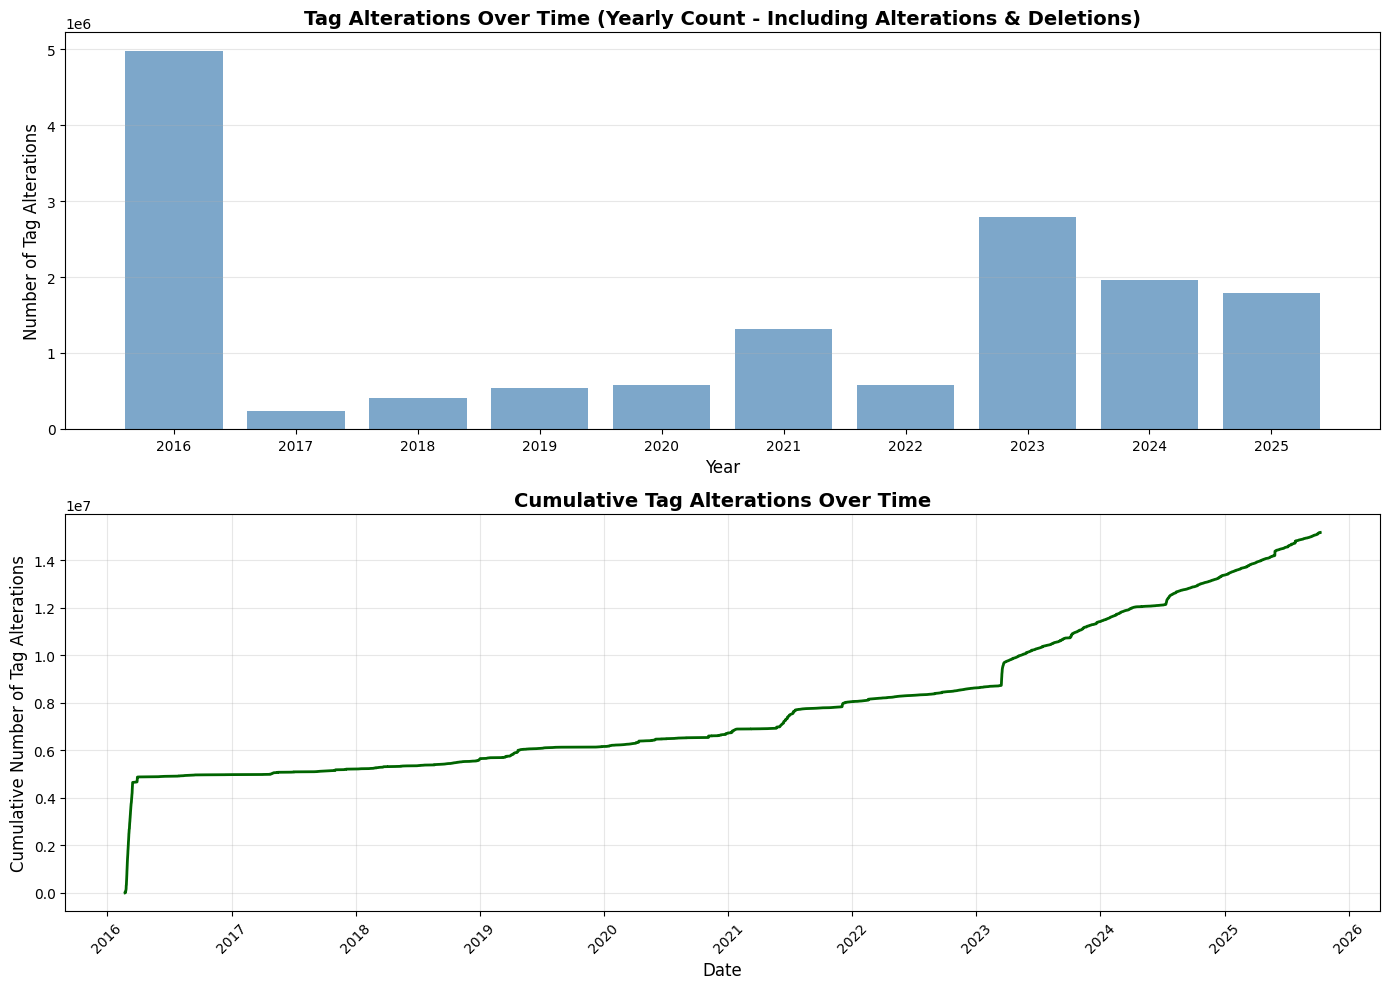

Total tag alterations plotted: 15_166_153
  - Tag Alterations: 613_087
  - Tag Deletions: 14_553_066
Date range: _ to _


In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

df_sorted = df.sort_values('new_snap_timestamp')
df_sorted['cumulative_count'] = range(1, len(df_sorted) + 1)

alterations_by_year = df.groupby('snap_year').size()

ax1.bar(alterations_by_year.index, alterations_by_year.values, width=0.8, alpha=0.7, color='steelblue')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Tag Alterations', fontsize=12)
ax1.set_title('Tag Alterations Over Time (Yearly Count - Including Alterations & Deletions)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(alterations_by_year.index)

ax2.plot(df_sorted['new_snap_timestamp'], 
         df_sorted['cumulative_count'], 
         linewidth=2, color='darkgreen')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cumulative Number of Tag Alterations', fontsize=12)
ax2.set_title('Cumulative Tag Alterations Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Total tag alterations plotted: {len(df):_}")
print(f"  - Tag Alterations: {len(tag_moves):_}")
print(f"  - Tag Deletions: {len(tag_deletions):_}")
print(f"Date range: {df['new_snap_timestamp'].min():_} to {df['new_snap_timestamp'].max():_}")

/tmp/ipykernel_2063297/3104661593.py:36: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/swh/scratch/rapaport/tags-alterations/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


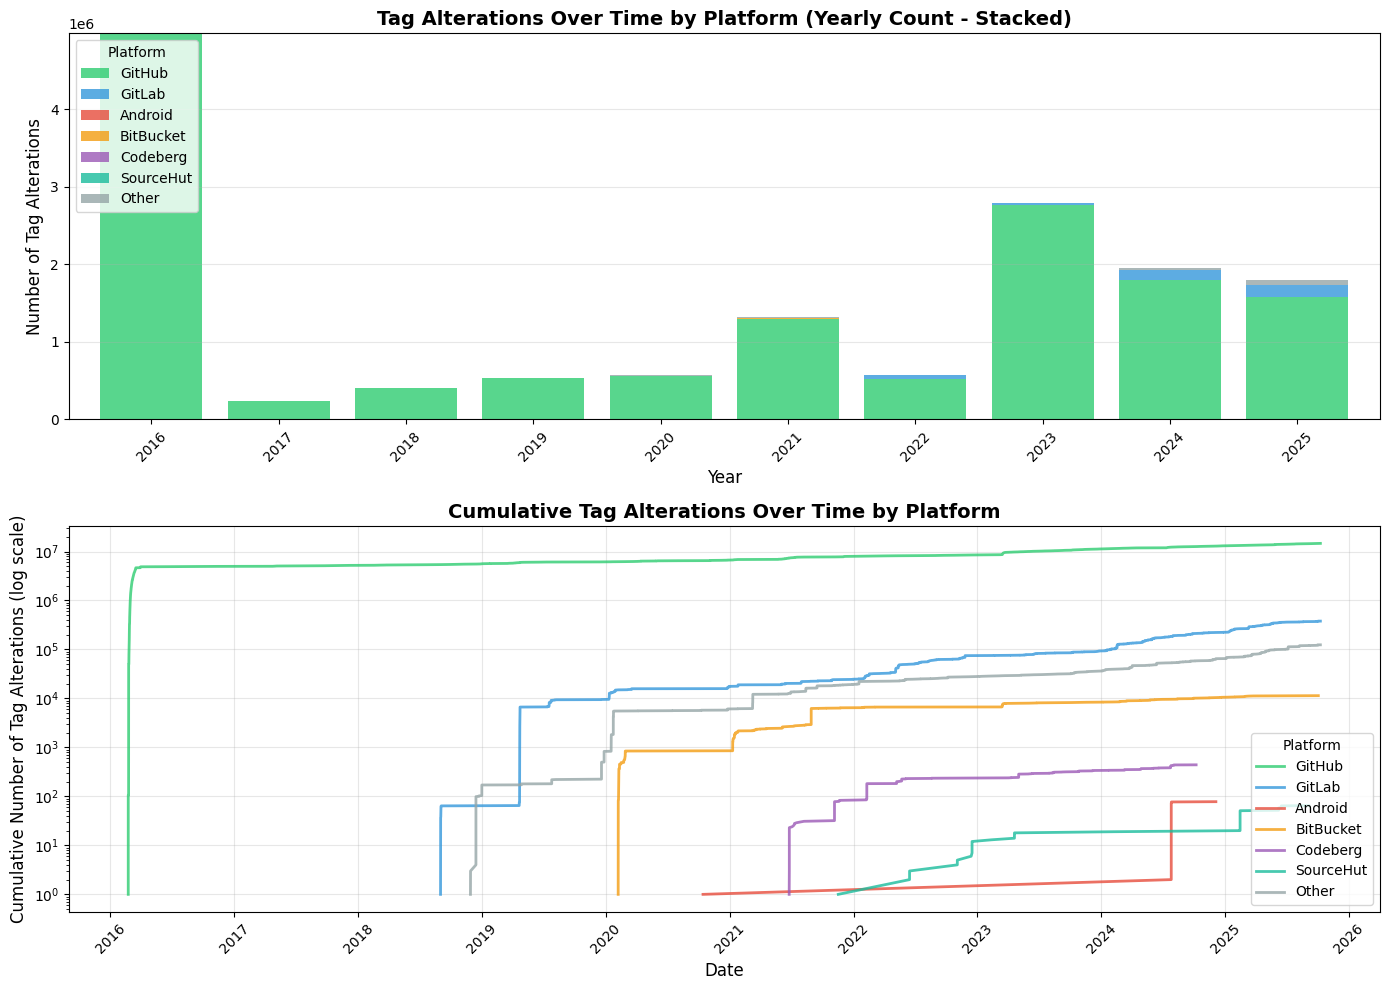

Platform distribution in the dataset:
  GitHub: 14650832 (96.6%)
  GitLab: 378996 (2.5%)
  Android: 78 (0.0%)
  BitBucket: 11391 (0.1%)
  Codeberg: 441 (0.0%)
  SourceHut: 65 (0.0%)
  Other: 124350 (0.8%)


In [21]:
# Platform comparison - Yearly and Cumulative Inconsistencies (All)
platforms = ['GitHub', 'GitLab', 'Android', 'BitBucket', 'Codeberg', 'SourceHut', 'Other']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#95a5a6']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Yearly count by platform
platform_by_year = df.groupby(['snap_year', 'platform']).size().unstack(fill_value=0)
platform_by_year = platform_by_year.reindex(columns=platforms, fill_value=0)

platform_by_year.plot(kind='bar', stacked=True, ax=ax1, color=colors, alpha=0.8, width=0.8)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Tag Alterations', fontsize=12)
ax1.set_title('Tag Alterations Over Time by Platform (Yearly Count - Stacked)', fontsize=14, fontweight='bold')
ax1.legend(title='Platform', fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Cumulative count by platform
for i, platform in enumerate(platforms):
    platform_df = df[df['platform'] == platform].sort_values('new_snap_timestamp')
    platform_df['cumulative_count'] = range(1, len(platform_df) + 1)
    if len(platform_df) > 0:
        ax2.plot(platform_df['new_snap_timestamp'], 
                 platform_df['cumulative_count'], 
                 linewidth=2, color=colors[i], label=platform, alpha=0.8)

ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cumulative Number of Tag Alterations (log scale)', fontsize=12)
ax2.set_title('Cumulative Tag Alterations Over Time by Platform', fontsize=14, fontweight='bold')
ax2.legend(title='Platform', fontsize=10)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Platform distribution in the dataset:")
for platform in platforms:
    count = len(df[df['platform'] == platform])
    print(f"  {platform}: {count} ({100*count/len(df):.1f}%)")

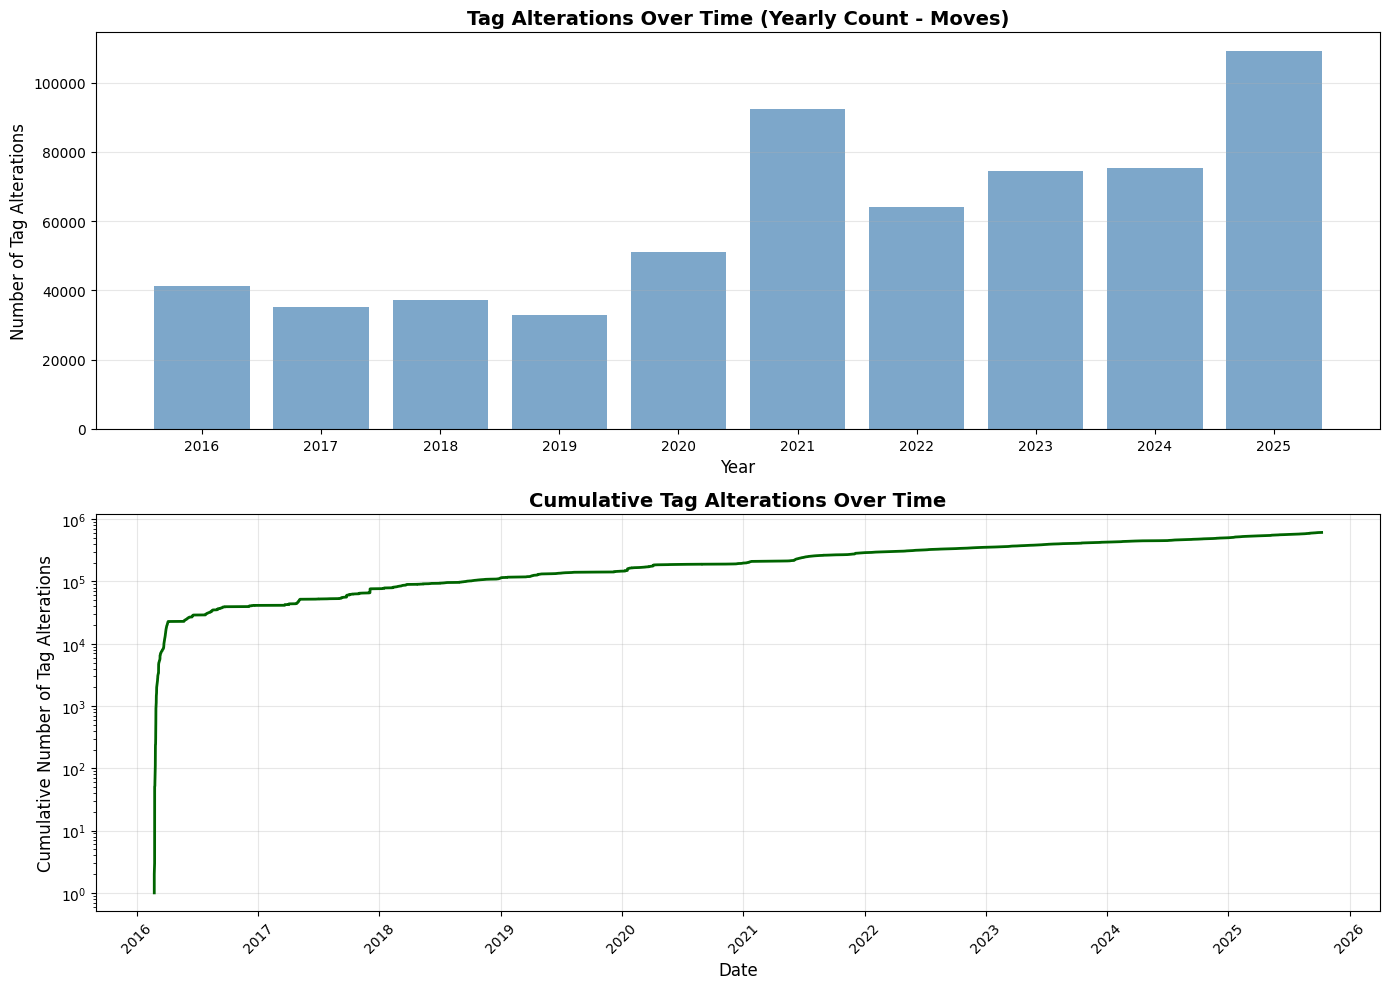

Total tag alterations plotted: 15166153
  - Tag Alterations: 613087
  - Tag Deletions: 14553066
Date range: 2016-02-22 16:56:16 to 2025-10-08 14:44:16


In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

df_sorted = tag_moves.sort_values('new_snap_timestamp')
df_sorted['cumulative_count'] = range(1, len(df_sorted) + 1)

alterations_by_year = tag_moves.groupby('snap_year').size()

ax1.bar(alterations_by_year.index, alterations_by_year.values, width=0.8, alpha=0.7, color='steelblue')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Tag Alterations', fontsize=12)
ax1.set_title('Tag Alterations Over Time (Yearly Count - Moves)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(alterations_by_year.index)

ax2.plot(df_sorted['new_snap_timestamp'], 
         df_sorted['cumulative_count'], 
         linewidth=2, color='darkgreen')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cumulative Number of Tag Alterations', fontsize=12)
ax2.set_title('Cumulative Tag Alterations Over Time', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Total tag alterations plotted: {len(df)}")
print(f"  - Tag Alterations: {len(tag_moves)}")
print(f"  - Tag Deletions: {len(tag_deletions)}")
print(f"Date range: {df['new_snap_timestamp'].min()} to {df['new_snap_timestamp'].max()}")

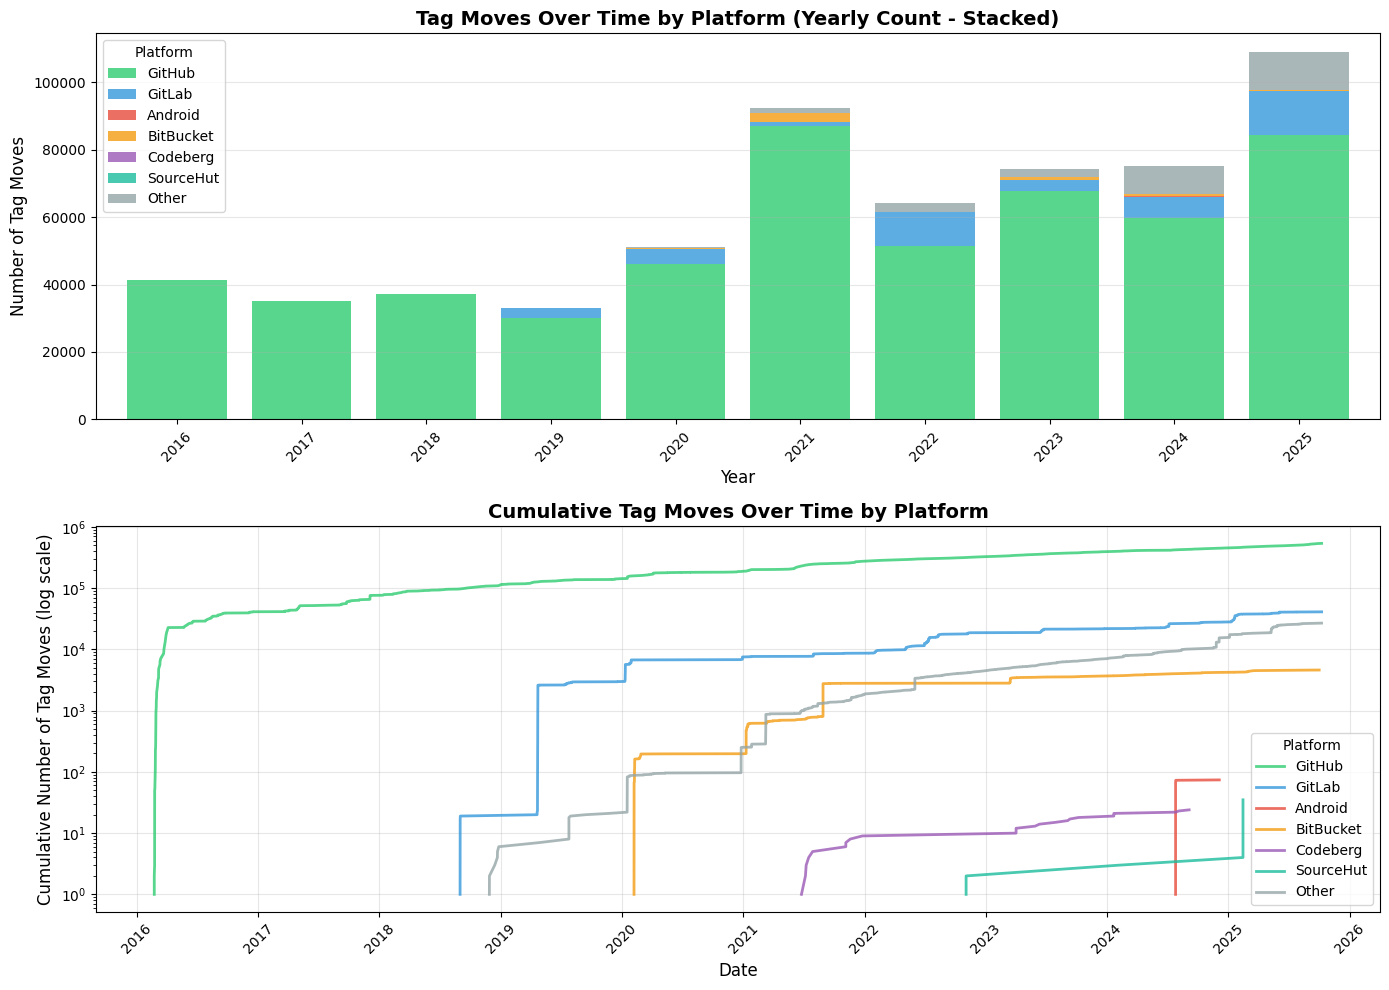

Platform distribution for tag moves:
  GitHub: 540269 (88.1%)
  GitLab: 41134 (6.7%)
  Android: 74 (0.0%)
  BitBucket: 4614 (0.8%)
  Codeberg: 24 (0.0%)
  SourceHut: 35 (0.0%)
  Other: 26937 (4.4%)


In [23]:
# Platform comparison - Yearly and Cumulative Moves (Alterations Only)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Yearly count by platform (alterations only)
platform_by_year_alt = tag_moves.groupby(['snap_year', 'platform']).size().unstack(fill_value=0)
platform_by_year_alt = platform_by_year_alt.reindex(columns=platforms, fill_value=0)

platform_by_year_alt.plot(kind='bar', stacked=True, ax=ax1, color=colors, alpha=0.8, width=0.8)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Tag Moves', fontsize=12)
ax1.set_title('Tag Moves Over Time by Platform (Yearly Count - Stacked)', fontsize=14, fontweight='bold')
ax1.legend(title='Platform', fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Cumulative count by platform (alterations only)
for i, platform in enumerate(platforms):
    platform_df = tag_moves[tag_moves['platform'] == platform].sort_values('new_snap_timestamp')
    platform_df['cumulative_count'] = range(1, len(platform_df) + 1)
    if len(platform_df) > 0:
        ax2.plot(platform_df['new_snap_timestamp'], 
                 platform_df['cumulative_count'], 
                 linewidth=2, color=colors[i], label=platform, alpha=0.8)

ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cumulative Number of Tag Moves (log scale)', fontsize=12)
ax2.set_title('Cumulative Tag Moves Over Time by Platform', fontsize=14, fontweight='bold')
ax2.legend(title='Platform', fontsize=10)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Platform distribution for tag moves:")
for platform in platforms:
    count = len(tag_moves[tag_moves['platform'] == platform])
    print(f"  {platform}: {count} ({100*count/len(tag_moves):.1f}%)")

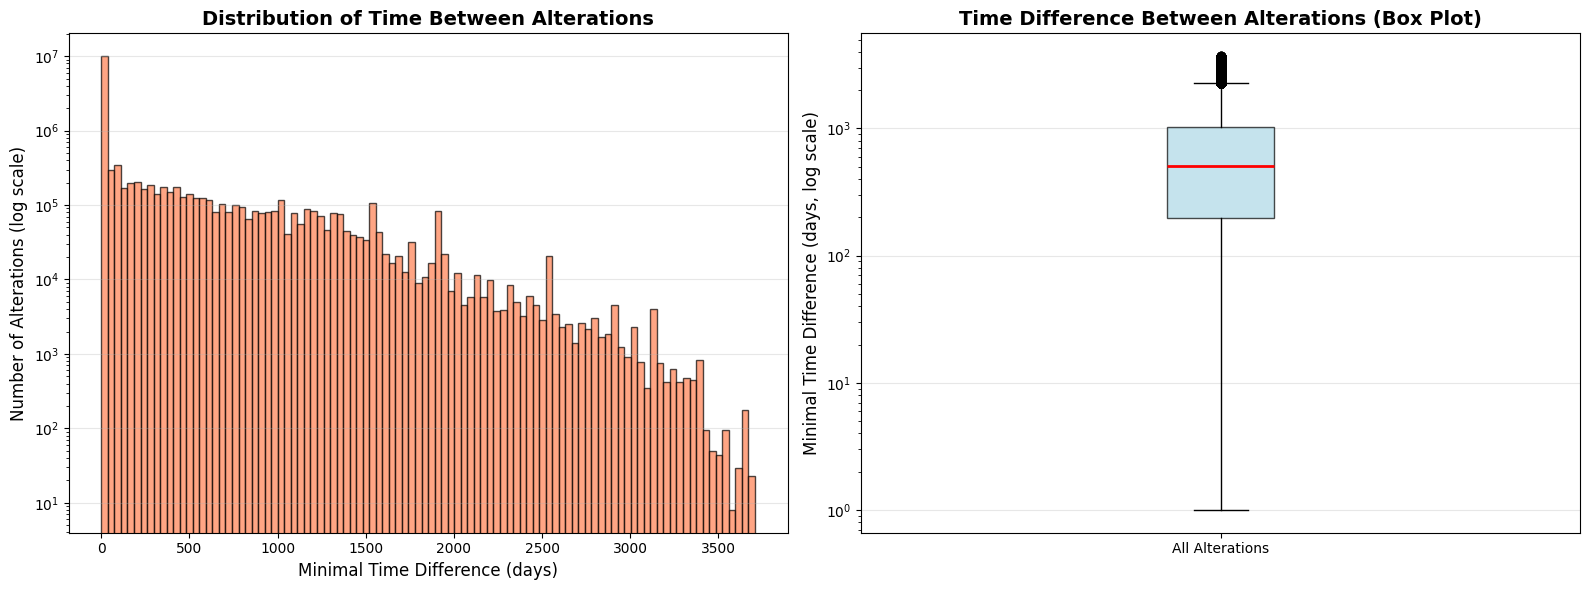

Time difference statistics:
  Mean: 240.97 days
  Median: 0.00 days
  Min: 0.00 days
  Max: 3707.00 days
  Std: 477.89 days


In [24]:
#df['time_diff_days'] = (df['new_snap_timestamp'] - df['old_snap_timestamp']).dt.total_seconds() / (24 * 3600)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

time_diffs_filtered = df['delta'].dropna()
ax1.hist(time_diffs_filtered, bins=100, alpha=0.7, color='coral', edgecolor='black')
ax1.set_xlabel('Minimal Time Difference (days)', fontsize=12)
ax1.set_ylabel('Number of Alterations (log scale)', fontsize=12)
ax1.set_title('Distribution of Time Between Alterations', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

ax2.boxplot([time_diffs_filtered[time_diffs_filtered > 0]], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Minimal Time Difference (days, log scale)', fontsize=12)
ax2.set_title('Time Difference Between Alterations (Box Plot)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(['All Alterations'])

plt.tight_layout()
plt.show()

print(f"Time difference statistics:")
print(f"  Mean: {time_diffs_filtered.mean():.2f} days")
print(f"  Median: {time_diffs_filtered.median():.2f} days")
print(f"  Min: {time_diffs_filtered.min():.2f} days")
print(f"  Max: {time_diffs_filtered.max():.2f} days")
print(f"  Std: {time_diffs_filtered.std():.2f} days")


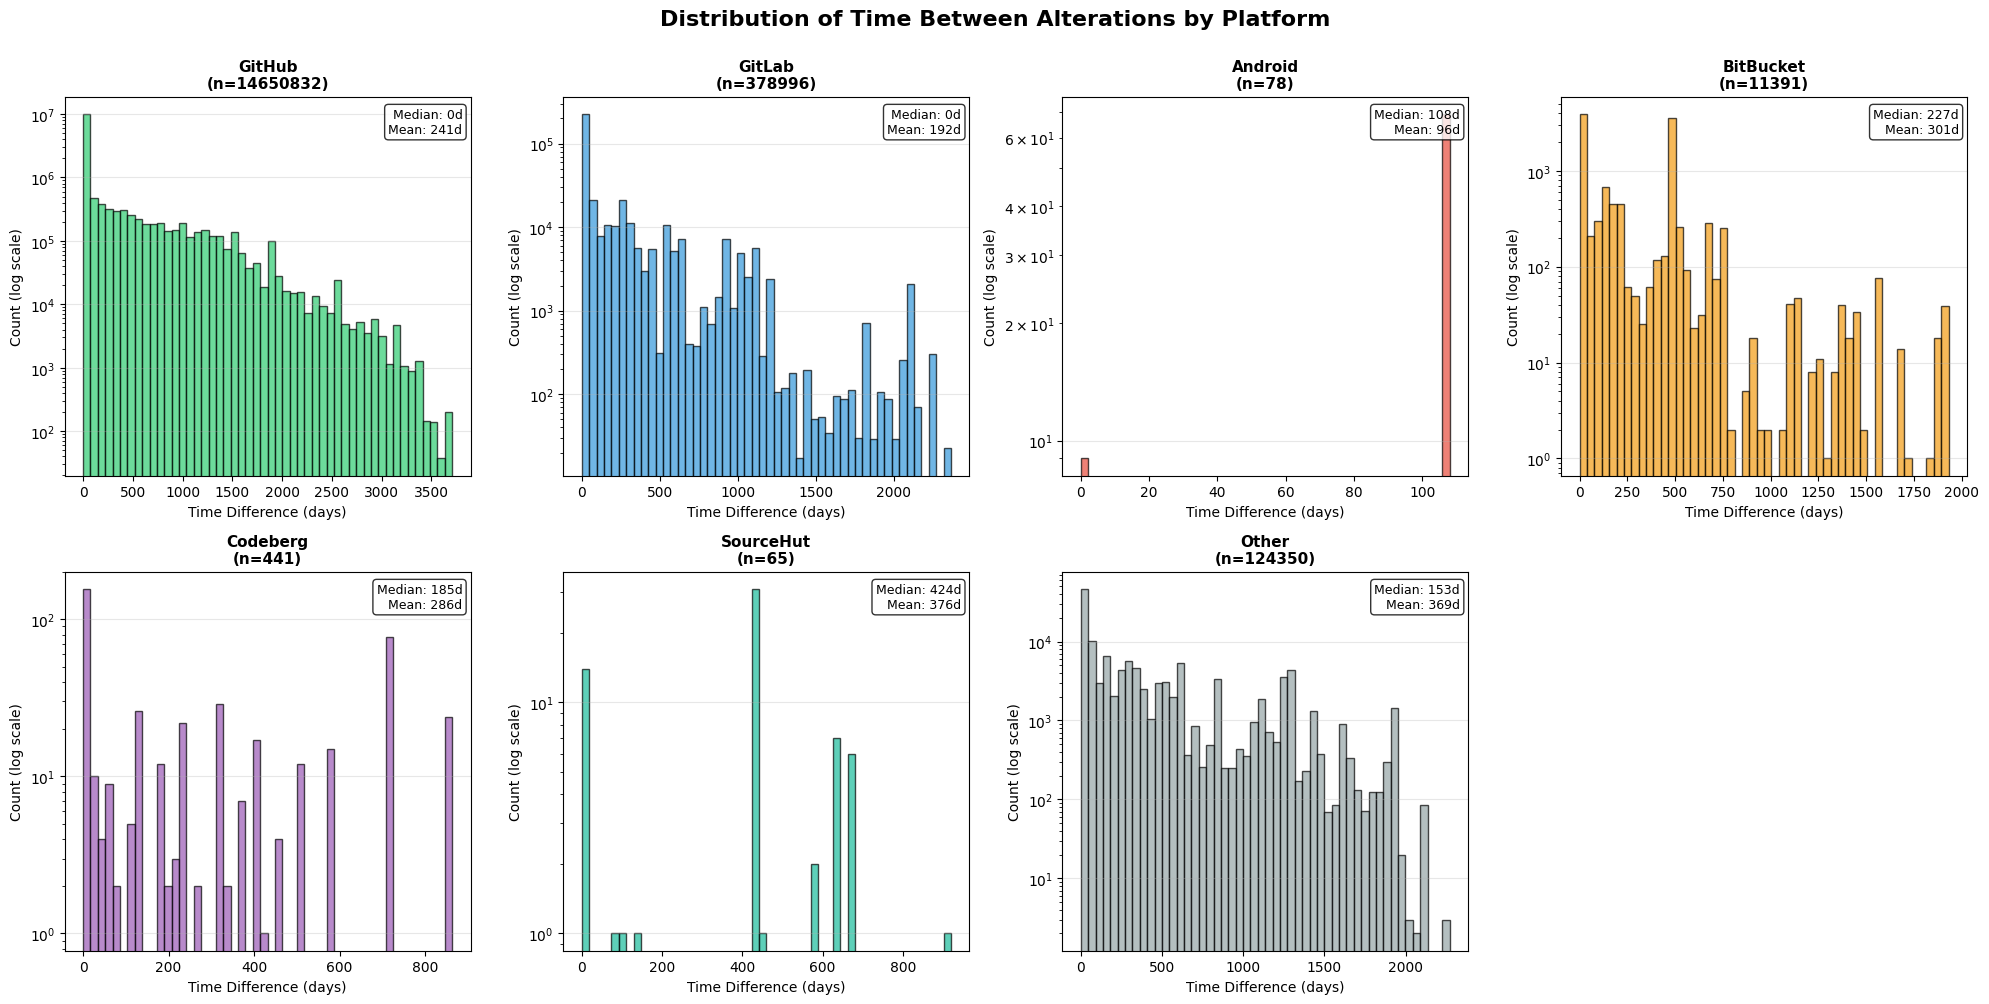

In [25]:
# Platform comparison - Time Between Alterations Distribution (All Inconsistencies)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, platform in enumerate(platforms):
    platform_df = df[df['platform'] == platform]
    time_diffs = platform_df['delta'].dropna()
    
    if len(time_diffs) > 0:
        axes[i].hist(time_diffs, bins=50, alpha=0.7, color=colors[i], edgecolor='black')
        axes[i].set_xlabel('Time Difference (days)', fontsize=10)
        axes[i].set_ylabel('Count (log scale)', fontsize=10)
        axes[i].set_title(f'{platform}\n(n={len(time_diffs)})', fontsize=11, fontweight='bold')
        axes[i].set_yscale('log')
        axes[i].grid(True, alpha=0.3, axis='y')
        
        # Add stats text
        stats_text = f'Median: {time_diffs.median():.0f}d\nMean: {time_diffs.mean():.0f}d'
        axes[i].text(0.98, 0.97, stats_text, transform=axes[i].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].set_title(f'{platform}\n(n=0)', fontsize=11, fontweight='bold')

# Hide the last subplot (7 platforms, 8 subplots)
axes[7].axis('off')

plt.suptitle('Distribution of Time Between Alterations by Platform', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

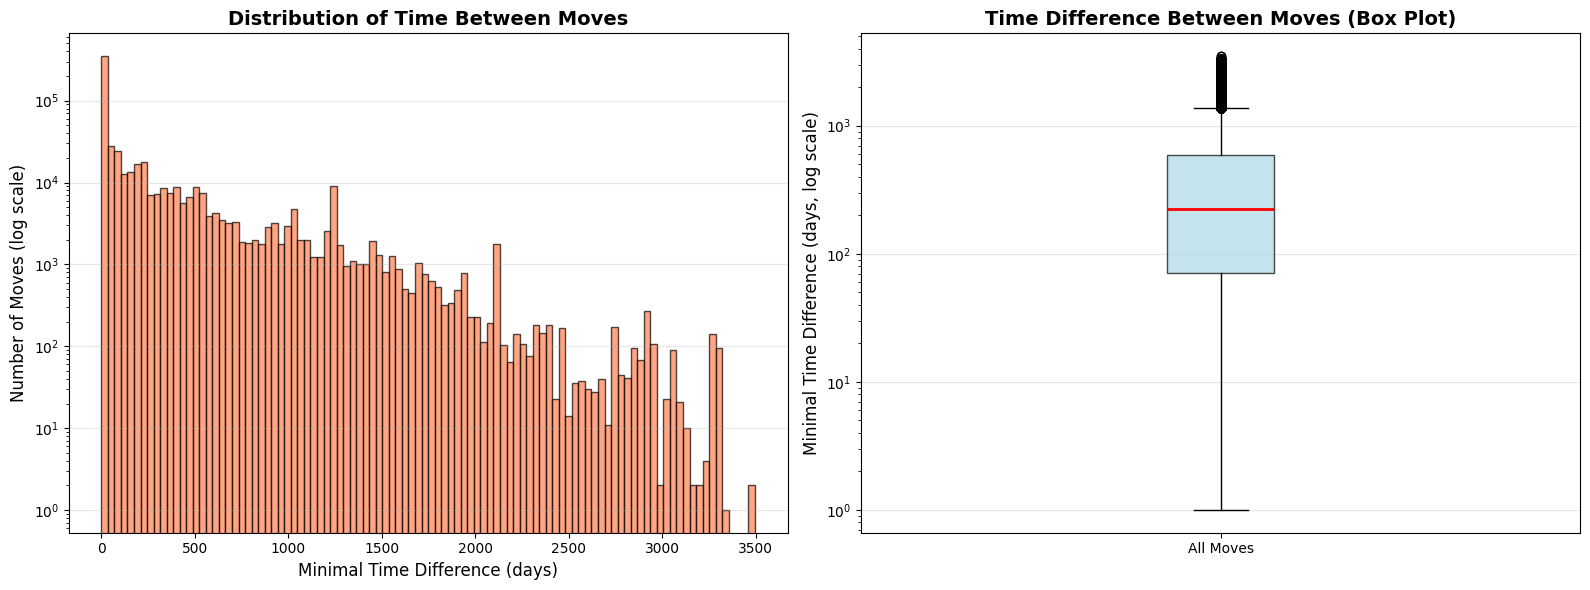

Time difference statistics:
  Mean: 221.04 days
  Median: 2.00 days
  Min: 0.00 days
  Max: 3496.00 days
  Std: 420.78 days


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

time_diffs_filtered = tag_moves['delta'].dropna()
ax1.hist(time_diffs_filtered, bins=100, alpha=0.7, color='coral', edgecolor='black')
ax1.set_xlabel('Minimal Time Difference (days)', fontsize=12)
ax1.set_ylabel('Number of Moves (log scale)', fontsize=12)
ax1.set_title('Distribution of Time Between Moves', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

ax2.boxplot([time_diffs_filtered[time_diffs_filtered > 0]], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Minimal Time Difference (days, log scale)', fontsize=12)
ax2.set_title('Time Difference Between Moves (Box Plot)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(['All Moves'])

plt.tight_layout()
plt.show()

print(f"Time difference statistics:")
print(f"  Mean: {time_diffs_filtered.mean():.2f} days")
print(f"  Median: {time_diffs_filtered.median():.2f} days")
print(f"  Min: {time_diffs_filtered.min():.2f} days")
print(f"  Max: {time_diffs_filtered.max():.2f} days")
print(f"  Std: {time_diffs_filtered.std():.2f} days")

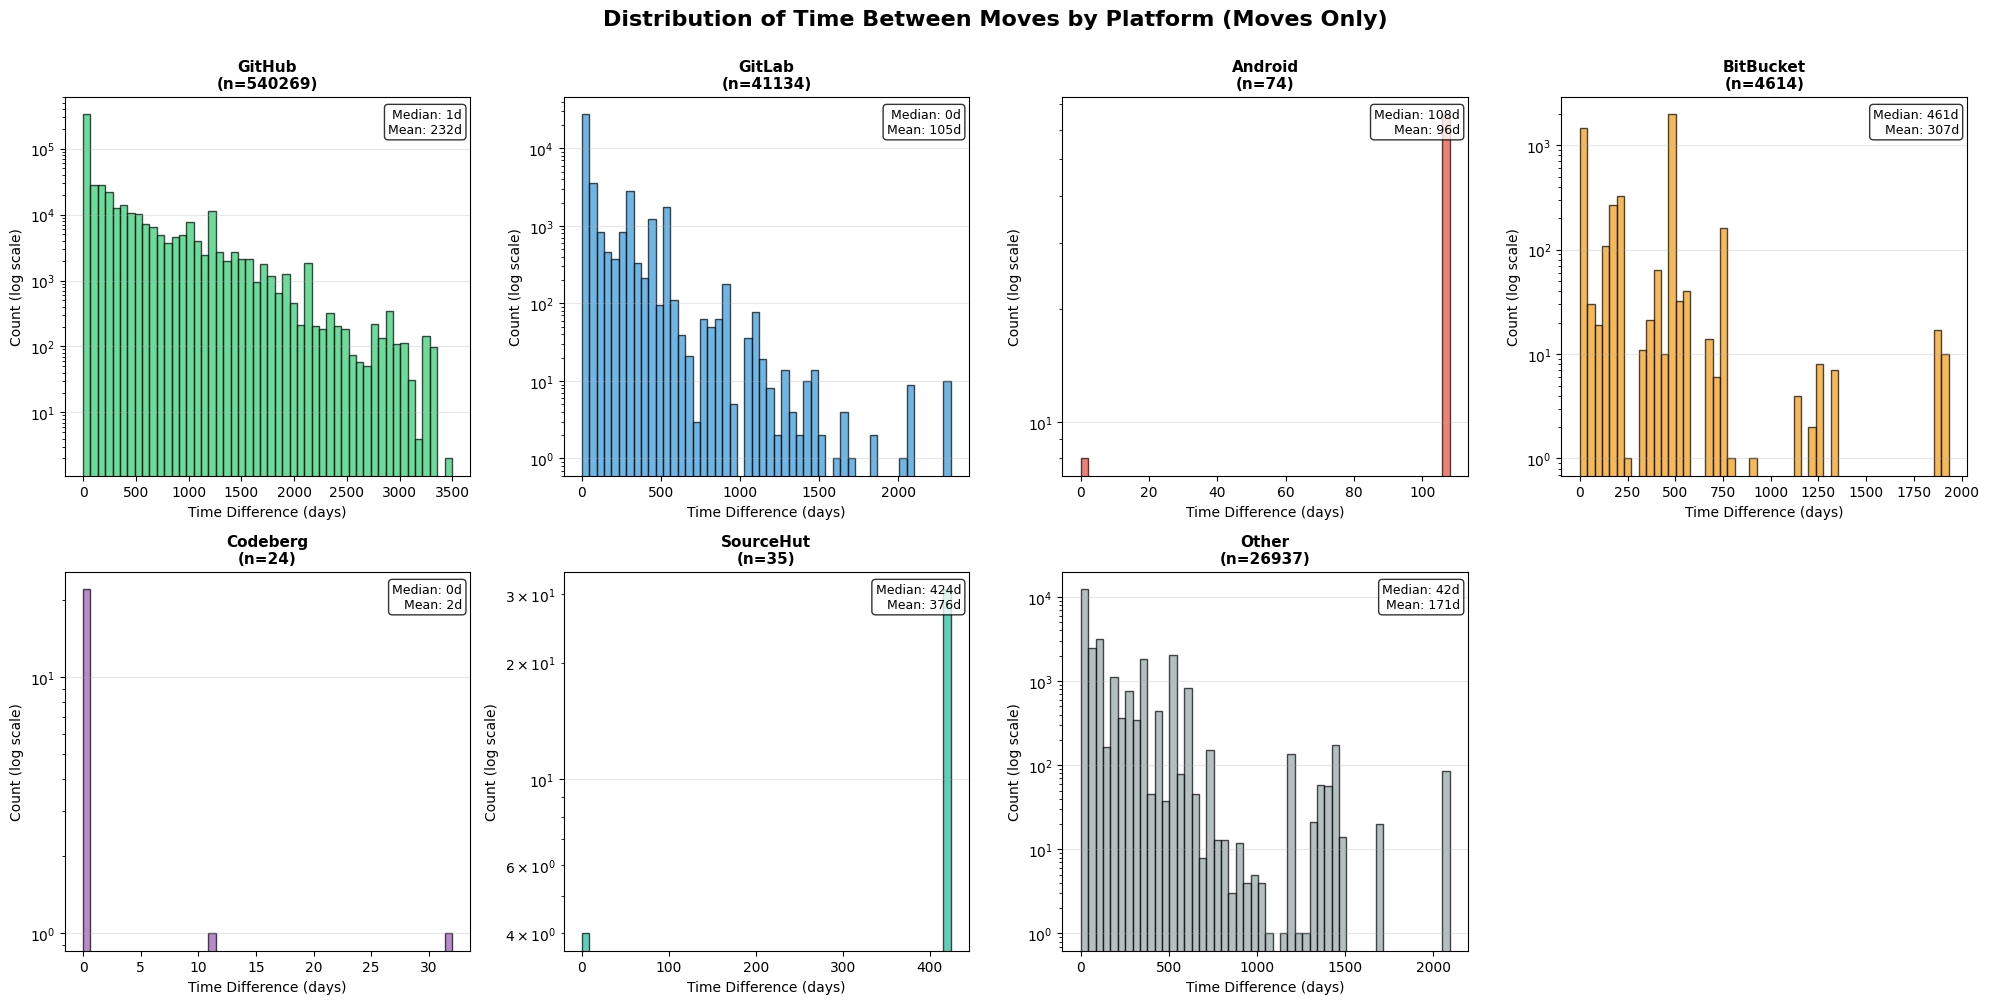

In [27]:
# Platform comparison - Time Between Moves Distribution (Alterations Only)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, platform in enumerate(platforms):
    platform_df = tag_moves[tag_moves['platform'] == platform]
    time_diffs = platform_df['delta'].dropna()
    
    if len(time_diffs) > 0:
        axes[i].hist(time_diffs, bins=50, alpha=0.7, color=colors[i], edgecolor='black')
        axes[i].set_xlabel('Time Difference (days)', fontsize=10)
        axes[i].set_ylabel('Count (log scale)', fontsize=10)
        axes[i].set_title(f'{platform}\n(n={len(time_diffs)})', fontsize=11, fontweight='bold')
        axes[i].set_yscale('log')
        axes[i].grid(True, alpha=0.3, axis='y')
        
        # Add stats text
        stats_text = f'Median: {time_diffs.median():.0f}d\nMean: {time_diffs.mean():.0f}d'
        axes[i].text(0.98, 0.97, stats_text, transform=axes[i].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].set_title(f'{platform}\n(n=0)', fontsize=11, fontweight='bold')

# Hide the last subplot
axes[7].axis('off')

plt.suptitle('Distribution of Time Between Moves by Platform (Moves Only)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

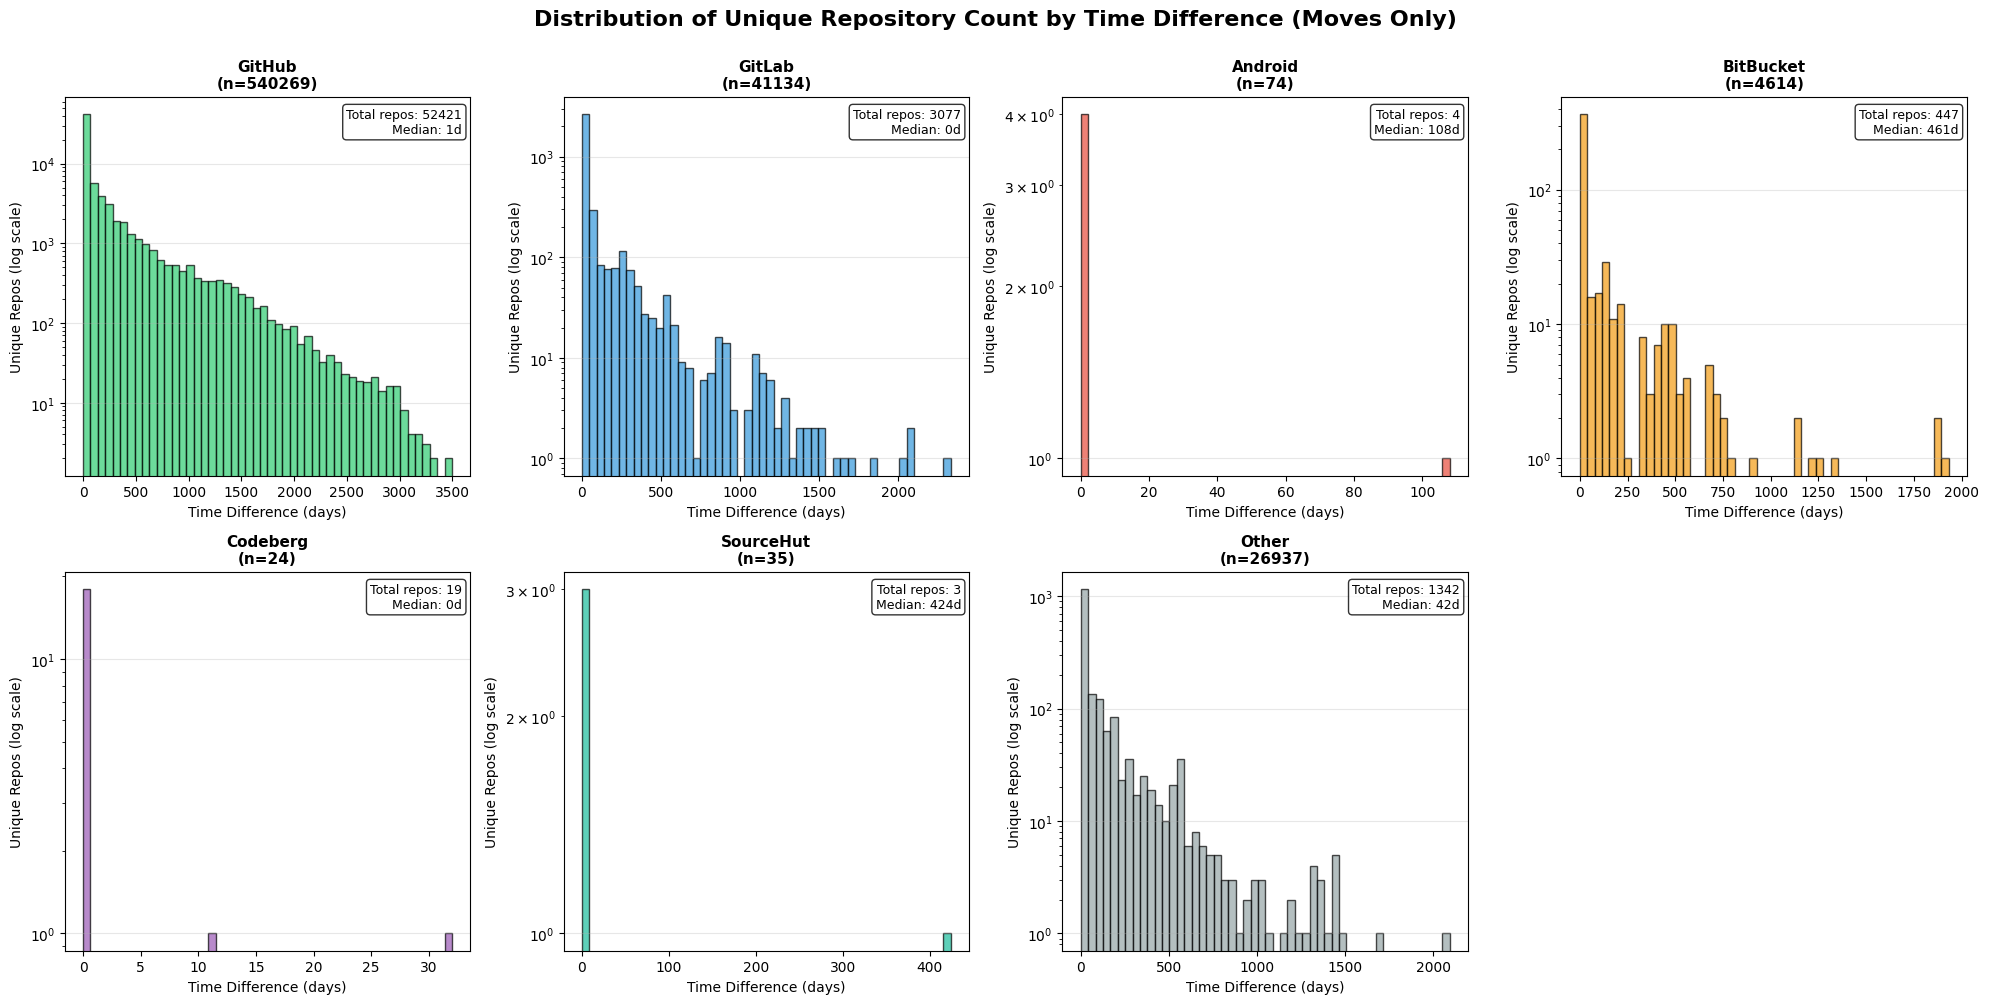

In [37]:
# Platform comparison - Unique Repository Count Distribution by Time (Moves Only)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, platform in enumerate(platforms):
    platform_df = tag_moves[tag_moves['platform'] == platform]
    
    if len(platform_df) > 0:
        # Group by delta bins and count unique repos
        time_diffs = platform_df['delta'].dropna()
        
        # Create histogram data for unique repos per time bin
        bins_edges = np.histogram_bin_edges(time_diffs, bins=50)
        platform_df_temp = platform_df.copy()
        platform_df_temp['delta_bin'] = pd.cut(platform_df_temp['delta'], bins=bins_edges, include_lowest=True)
        
        # Count unique repos per bin
        unique_repos_per_bin = platform_df_temp.groupby('delta_bin', observed=True)['origin_url'].nunique()
        
        # Get bin centers and widths for plotting
        bin_centers = [(b.left + b.right) / 2 for b in unique_repos_per_bin.index]
        bin_widths = [b.right - b.left for b in unique_repos_per_bin.index]
        
        axes[i].bar(bin_centers, unique_repos_per_bin.values, 
                   width=bin_widths, alpha=0.7, color=colors[i], edgecolor='black')
        axes[i].set_xlabel('Time Difference (days)', fontsize=10)
        axes[i].set_ylabel('Unique Repos (log scale)', fontsize=10)
        axes[i].set_title(f'{platform}\n(n={len(platform_df)})', fontsize=11, fontweight='bold')
        axes[i].set_yscale('log')
        axes[i].grid(True, alpha=0.3, axis='y')
        
        # Add stats text
        total_unique_repos = platform_df['origin_url'].nunique()
        stats_text = f'Total repos: {total_unique_repos}\nMedian: {time_diffs.median():.0f}d'
        axes[i].text(0.98, 0.97, stats_text, transform=axes[i].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].set_title(f'{platform}\n(n=0)', fontsize=11, fontweight='bold')

# Hide the last subplot
axes[7].axis('off')

plt.suptitle('Distribution of Unique Repository Count by Time Difference (Moves Only)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

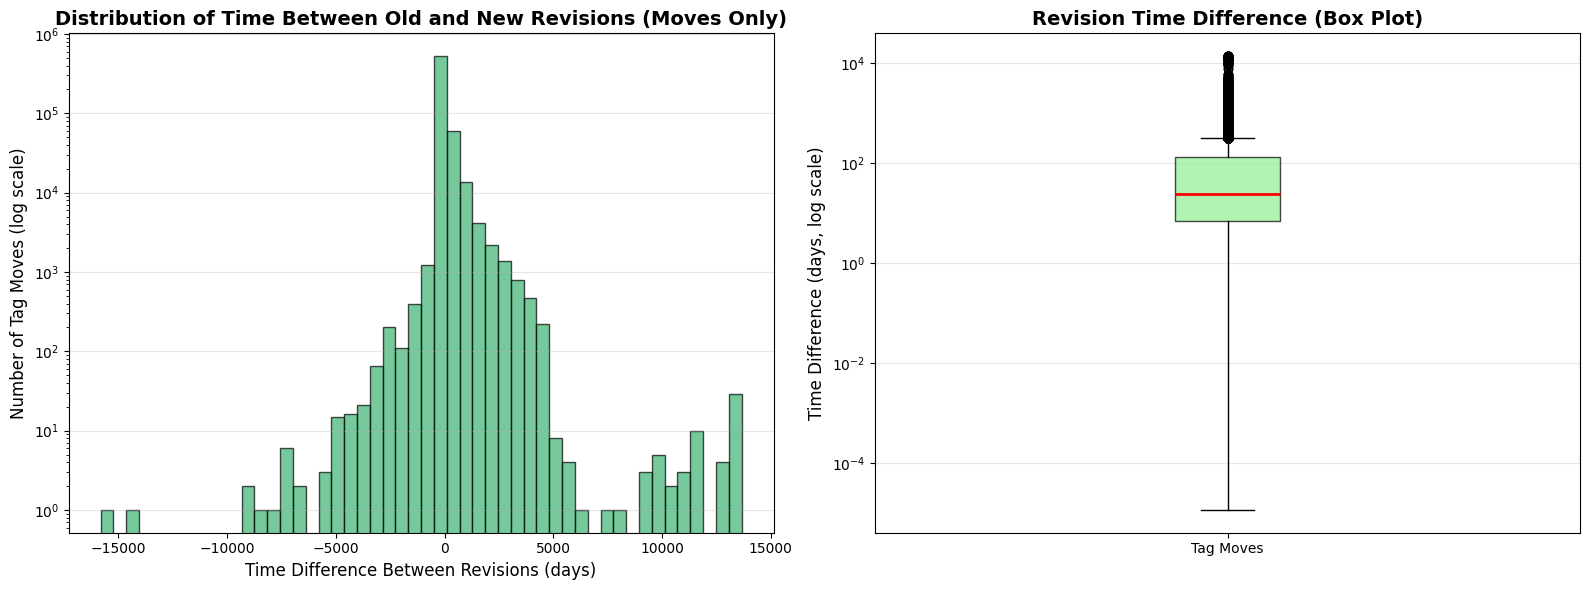

Revision time difference statistics (for 613087 moves):
  Mean: 85.81 days
  Median: 0.00 days
  Min: -15807.67 days
  Max: 13654.97 days
  Std: 363.30 days
  Negative values (new revision older than old): 27605


In [28]:
tag_moves['rev_time_diff_days'] = (tag_moves['new_rev_timestamp'] - tag_moves['old_rev_timestamp']).dt.total_seconds() / (24 * 3600)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

rev_time_diffs = tag_moves['rev_time_diff_days'].dropna()
ax1.hist(rev_time_diffs, bins=50, alpha=0.7, color='mediumseagreen', edgecolor='black')
ax1.set_xlabel('Time Difference Between Revisions (days)', fontsize=12)
ax1.set_ylabel('Number of Tag Moves (log scale)', fontsize=12)
ax1.set_title('Distribution of Time Between Old and New Revisions (Moves Only)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_yscale('log')

positive_rev_diffs = rev_time_diffs[rev_time_diffs > 0]
if len(positive_rev_diffs) > 0:
    ax2.boxplot([positive_rev_diffs], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
    ax2.set_ylabel('Time Difference (days, log scale)', fontsize=12)
    ax2.set_title('Revision Time Difference (Box Plot)', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_xticklabels(['Tag Moves'])

plt.tight_layout()
plt.show()

print(f"Revision time difference statistics (for {len(tag_moves)} moves):")
print(f"  Mean: {rev_time_diffs.mean():.2f} days")
print(f"  Median: {rev_time_diffs.median():.2f} days")
print(f"  Min: {rev_time_diffs.min():.2f} days")
print(f"  Max: {rev_time_diffs.max():.2f} days")
print(f"  Std: {rev_time_diffs.std():.2f} days")
print(f"  Negative values (new revision older than old): {len(rev_time_diffs[rev_time_diffs < 0])}")

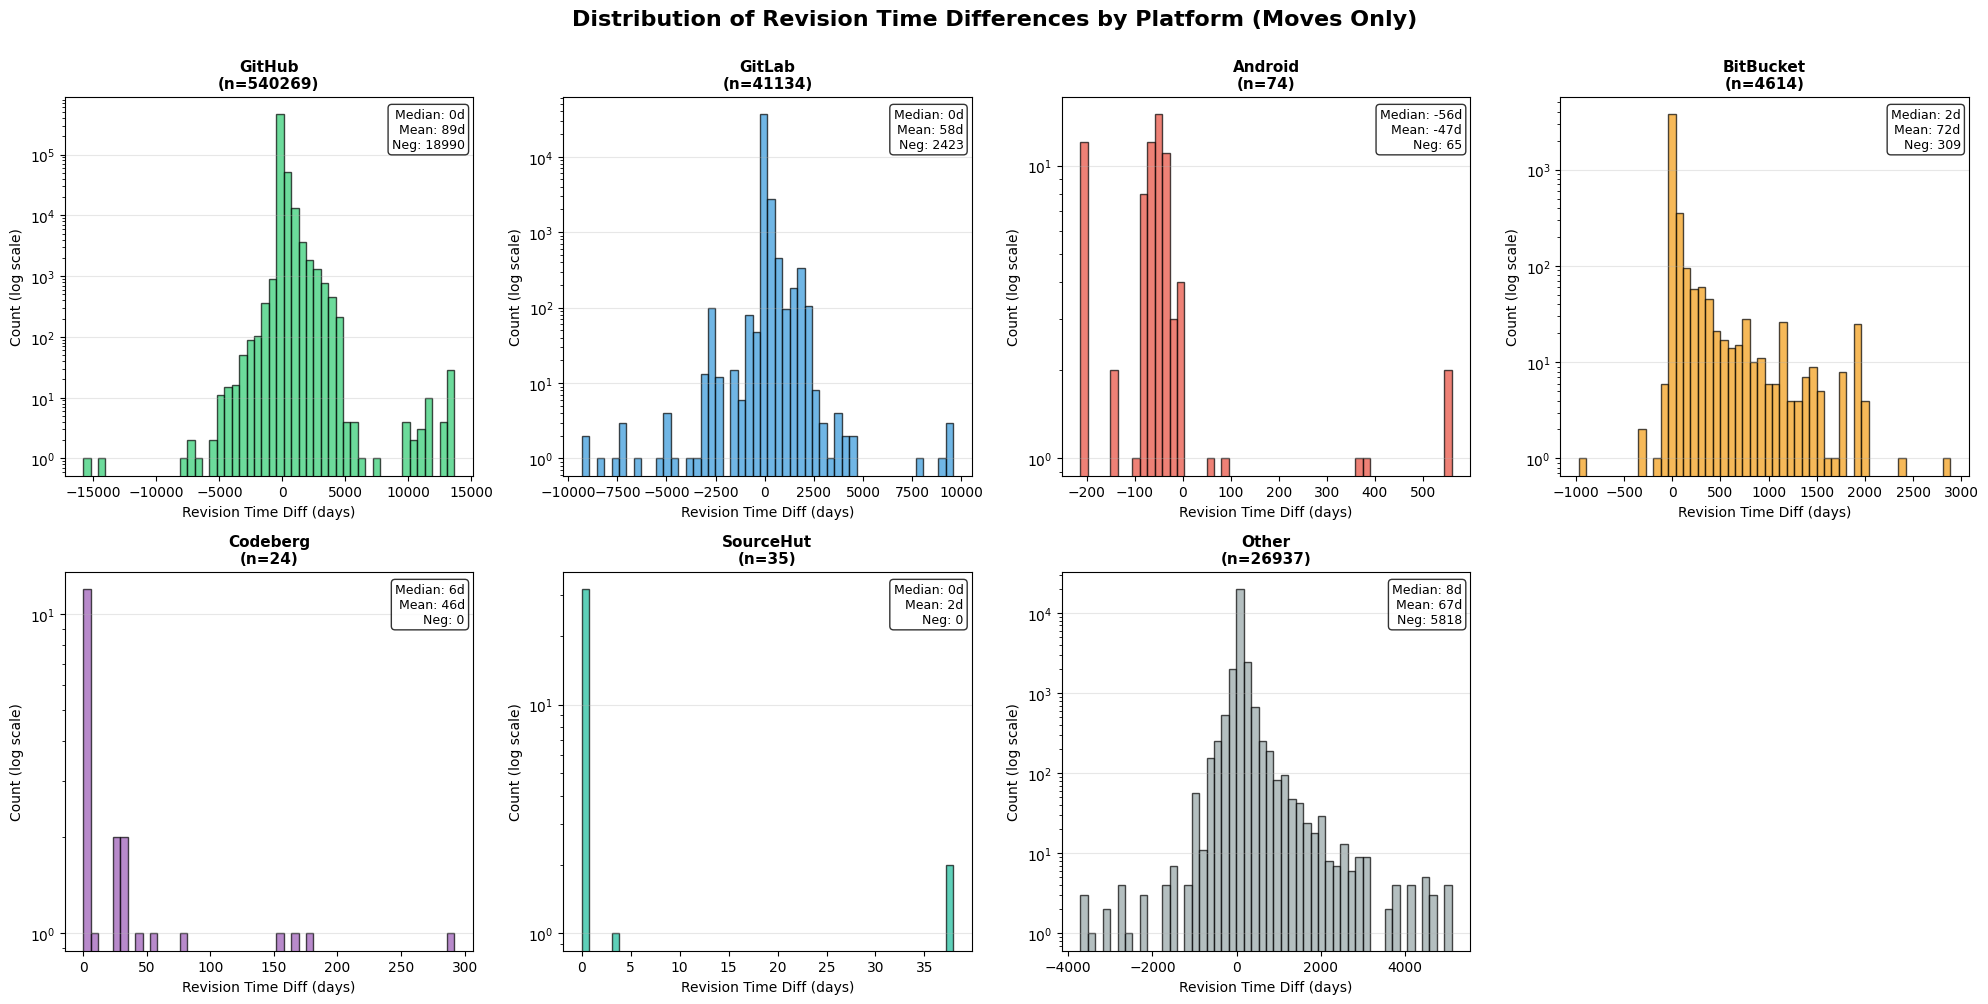

In [29]:
# Platform comparison - Revision Time Difference Distribution (Alterations Only)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, platform in enumerate(platforms):
    platform_df = tag_moves[tag_moves['platform'] == platform]
    rev_time_diffs = platform_df['rev_time_diff_days'].dropna()
    
    if len(rev_time_diffs) > 0:
        axes[i].hist(rev_time_diffs, bins=50, alpha=0.7, color=colors[i], edgecolor='black')
        axes[i].set_xlabel('Revision Time Diff (days)', fontsize=10)
        axes[i].set_ylabel('Count (log scale)', fontsize=10)
        axes[i].set_title(f'{platform}\n(n={len(rev_time_diffs)})', fontsize=11, fontweight='bold')
        axes[i].set_yscale('log')
        axes[i].grid(True, alpha=0.3, axis='y')
        
        # Add stats text
        negative_count = len(rev_time_diffs[rev_time_diffs < 0])
        stats_text = f'Median: {rev_time_diffs.median():.0f}d\nMean: {rev_time_diffs.mean():.0f}d\nNeg: {negative_count}'
        axes[i].text(0.98, 0.97, stats_text, transform=axes[i].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].set_title(f'{platform}\n(n=0)', fontsize=11, fontweight='bold')

# Hide the last subplot
axes[7].axis('off')

plt.suptitle('Distribution of Revision Time Differences by Platform (Moves Only)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

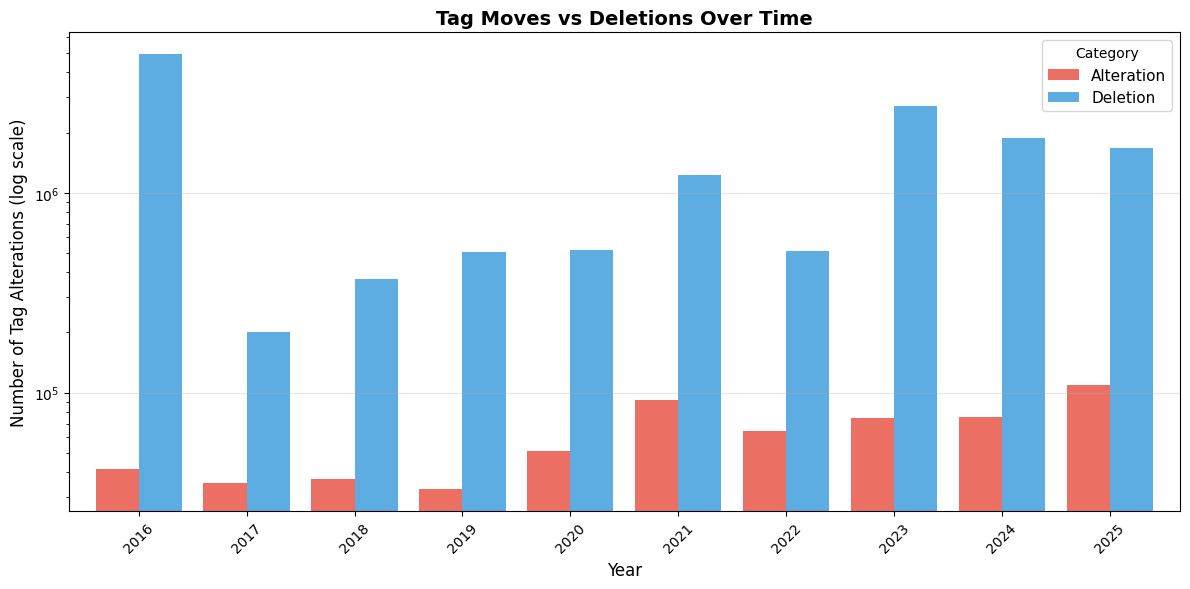


Yearly breakdown:
category   Alteration  Deletion
snap_year                      
2016            41306   4935043
2017            35150    200227
2018            37179    371544
2019            32935    505936
2020            51088    519774
2021            92447   1225935
2022            64166    512516
2023            74402   2718666
2024            75322   1880295
2025           109092   1683130

Total Moves: 613087
Total Deletions: 14553066


In [30]:
inconsistencies_by_year_type = df.groupby(['snap_year', 'category']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

inconsistencies_by_year_type.plot(kind='bar', ax=ax, 
                                   color=['#e74c3c', '#3498db'], alpha=0.8, width=0.8)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Tag Alterations (log scale)', fontsize=12)
ax.set_title('Tag Moves vs Deletions Over Time', fontsize=14, fontweight='bold')
ax.legend(title='Category', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)
ax.set_yscale('log')  # Log scale to see alterations better

plt.tight_layout()
plt.show()

print("\nYearly breakdown:")
print(inconsistencies_by_year_type)
print(f"\nTotal Moves: {inconsistencies_by_year_type['Alteration'].sum()}")
print(f"Total Deletions: {inconsistencies_by_year_type['Deletion'].sum()}")

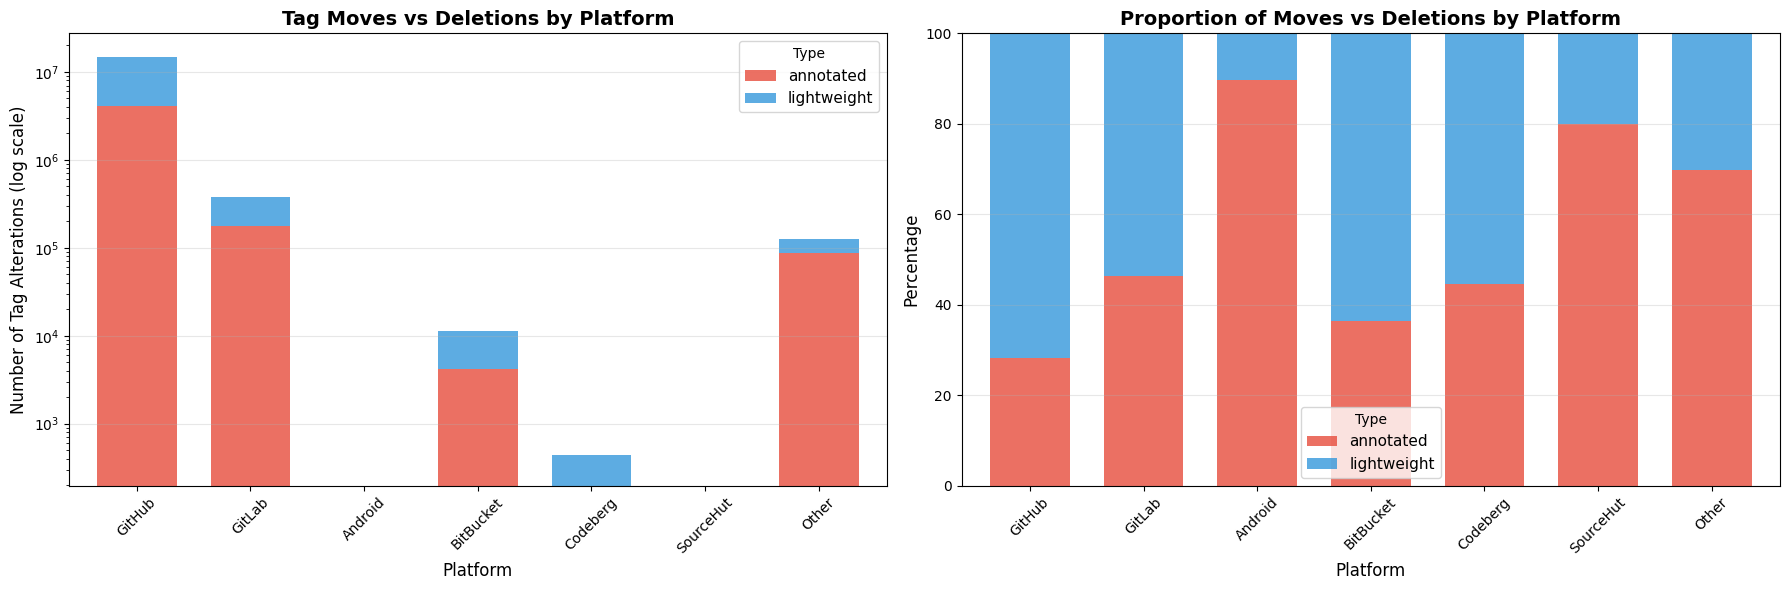


Breakdown by platform:
type       annotated  lightweight
platform                         
GitHub       4144353     10506479
GitLab        175375       203621
Android           70            8
BitBucket       4159         7232
Codeberg         197          244
SourceHut         52           13
Other          86695        37655

Percentages:
type       annotated  lightweight
platform                         
GitHub          28.3         71.7
GitLab          46.3         53.7
Android         89.7         10.3
BitBucket       36.5         63.5
Codeberg        44.7         55.3
SourceHut       80.0         20.0
Other           69.7         30.3


In [31]:
# Platform comparison - Alterations vs Deletions by Platform
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Count by platform and type
platform_type_counts = df.groupby(['platform', 'type']).size().unstack(fill_value=0)
platform_type_counts = platform_type_counts.reindex(index=platforms, fill_value=0)

# Stacked bar chart
platform_type_counts.plot(kind='bar', stacked=True, ax=ax1, 
                          color=['#e74c3c', '#3498db'], alpha=0.8, width=0.7)
ax1.set_xlabel('Platform', fontsize=12)
ax1.set_ylabel('Number of Tag Alterations (log scale)', fontsize=12)
ax1.set_title('Tag Moves vs Deletions by Platform', fontsize=14, fontweight='bold')
ax1.legend(title='Type', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)
ax1.set_yscale('log')

# Proportion chart
platform_type_pct = platform_type_counts.div(platform_type_counts.sum(axis=1), axis=0) * 100
platform_type_pct.plot(kind='bar', stacked=True, ax=ax2, 
                       color=['#e74c3c', '#3498db'], alpha=0.8, width=0.7)
ax2.set_xlabel('Platform', fontsize=12)
ax2.set_ylabel('Percentage', fontsize=12)
ax2.set_title('Proportion of Moves vs Deletions by Platform', fontsize=14, fontweight='bold')
ax2.legend(title='Type', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\nBreakdown by platform:")
print(platform_type_counts)
print("\nPercentages:")
print(platform_type_pct.round(1))

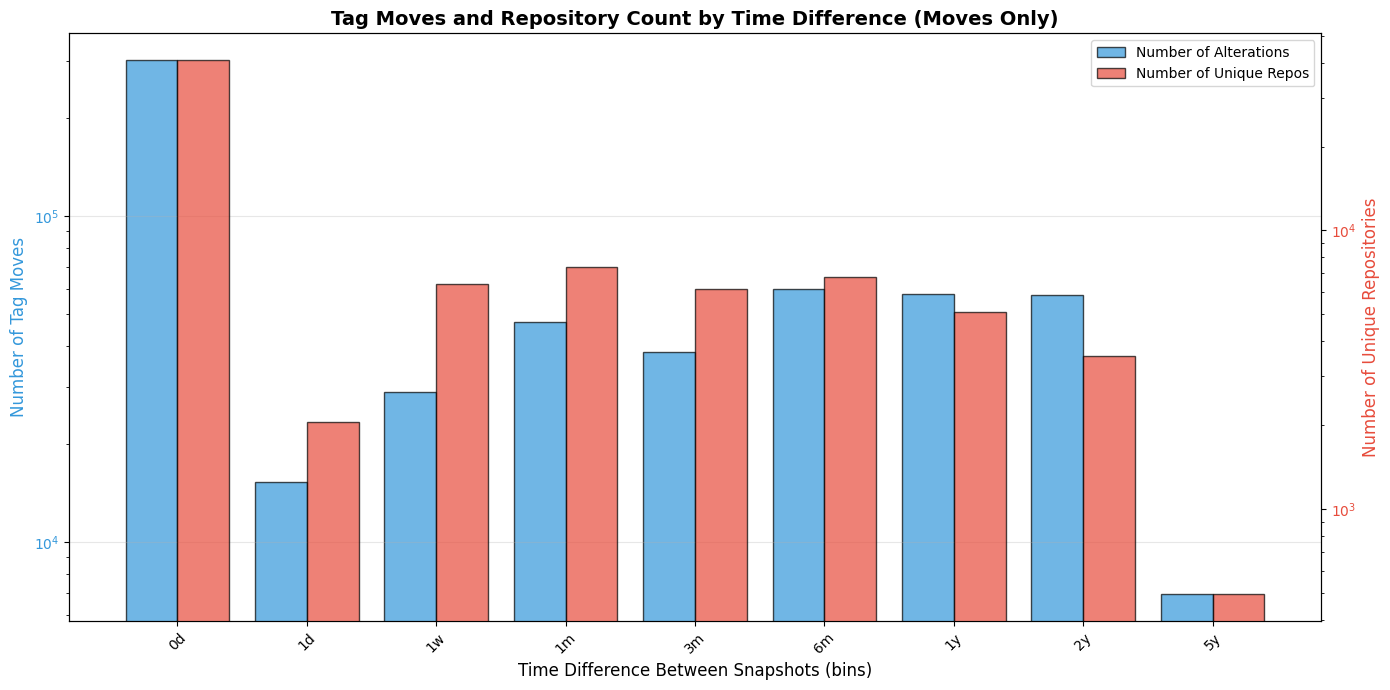

Tag moves and repository distribution by time difference bin:
           Alterations  Unique Repos  Avg Alterations per Repo
delta_bin                                                     
0d              301539         40907                      7.37
1d               15352          2044                      7.51
1w               28889          6412                      4.51
1m               47326          7393                      6.40
3m               38354          6133                      6.25
6m               59652          6825                      8.74
1y               57716          5104                     11.31
2y               57331          3550                     16.15
5y                6928           493                     14.05

Total tag moves analyzed: 613_087
Total unique repositories: 57_313


In [32]:
# Repository count vs Alteration count by Time Difference (Dual-axis plot)
# Bin the delta values
bins = [0, 1, 7, 30, 90, 180, 365, 730, 1825, 3650, float('inf')]
bin_labels = ['0d', '1d', '1w', '1m', '3m', '6m', '1y', '2y', '5y', '10y+']

tag_moves_binned = tag_moves.copy()
tag_moves_binned['delta_bin'] = pd.cut(tag_moves_binned['delta'], bins=bins, labels=bin_labels, right=False)

# Count alterations and unique repos per bin
alterations_per_bin = tag_moves_binned.groupby('delta_bin', observed=True).size()
repos_per_bin = tag_moves_binned.groupby('delta_bin', observed=True)['origin_url'].nunique()

fig, ax1 = plt.subplots(figsize=(14, 7))

x_pos = np.arange(len(alterations_per_bin))

# Plot alterations on left y-axis
color1 = '#3498db'
bars1 = ax1.bar(x_pos - 0.2, alterations_per_bin.values, width=0.4, alpha=0.7, 
                color=color1, label='Number of Alterations', edgecolor='black')
ax1.set_xlabel('Time Difference Between Snapshots (bins)', fontsize=12)
ax1.set_ylabel('Number of Tag Moves', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

# Plot repos on right y-axis
ax2 = ax1.twinx()
color2 = '#e74c3c'
bars2 = ax2.bar(x_pos + 0.2, repos_per_bin.values, width=0.4, alpha=0.7, 
                color=color2, label='Number of Unique Repos', edgecolor='black')
ax2.set_ylabel('Number of Unique Repositories', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_yscale('log')

# Set x-axis
ax1.set_xticks(x_pos)
ax1.set_xticklabels(alterations_per_bin.index, rotation=45)
ax1.set_title('Tag Moves and Repository Count by Time Difference (Moves Only)', 
              fontsize=14, fontweight='bold')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("Tag moves and repository distribution by time difference bin:")
summary_df = pd.DataFrame({
    'Alterations': alterations_per_bin,
    'Unique Repos': repos_per_bin,
    'Avg Alterations per Repo': (alterations_per_bin / repos_per_bin).round(2)
})
print(summary_df)
print(f"\nTotal tag moves analyzed: {len(tag_moves):_}")
print(f"Total unique repositories: {tag_moves['origin_url'].nunique():_}")

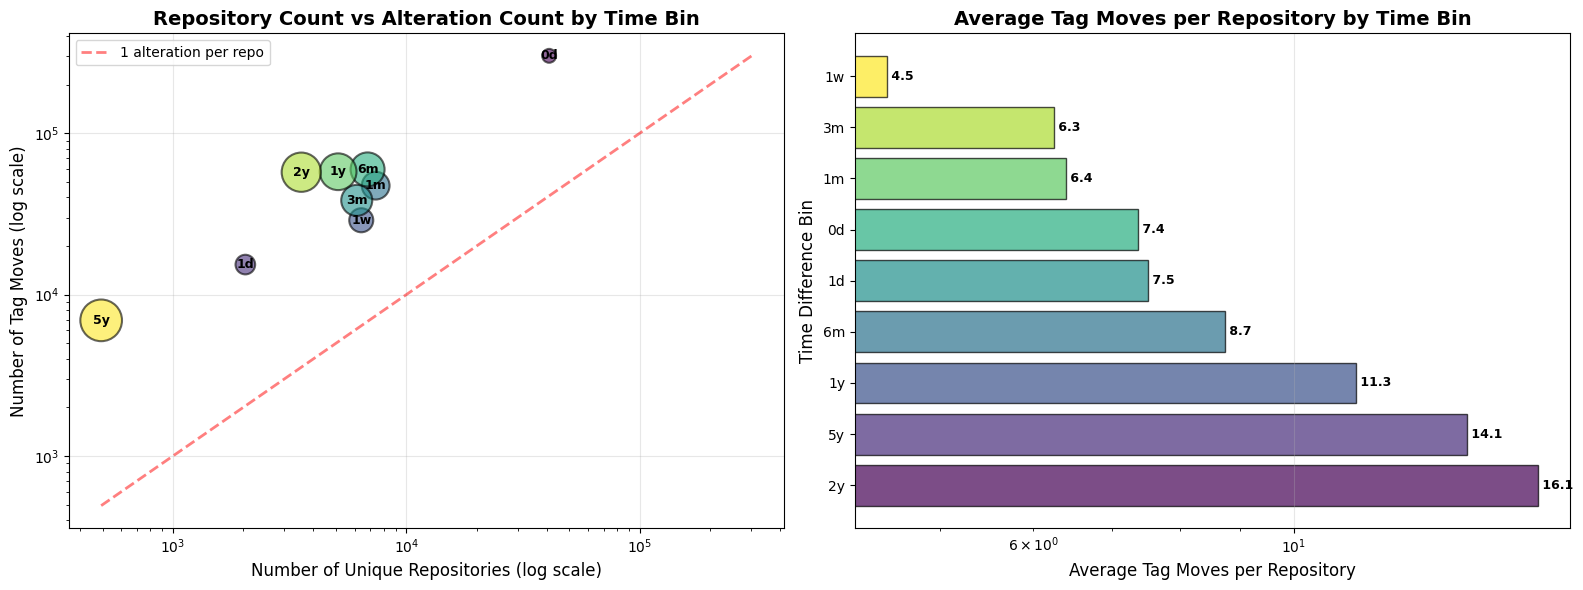


Key insights:
Bins with highest concentration (most alterations per repo):
delta_bin
2y    16.149577
5y    14.052738
1y    11.307994
dtype: float64

Bins with widest distribution (most repos involved):
delta_bin
0d    40907
1m     7393
6m     6825
Name: origin_url, dtype: int64


In [33]:
# Repository count vs Alteration count scatter plot
# This shows the relationship between number of alterations and number of repos per bin
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: alterations vs repos per bin
scatter_sizes = [100 * (i + 1) for i in range(len(alterations_per_bin))]
scatter = ax1.scatter(repos_per_bin.values, alterations_per_bin.values, 
                      s=scatter_sizes, alpha=0.6, c=range(len(alterations_per_bin)), 
                      cmap='viridis', edgecolors='black', linewidth=1.5)

# Add bin labels to points
for i, (x, y, label) in enumerate(zip(repos_per_bin.values, alterations_per_bin.values, bin_labels)):
    ax1.annotate(label, (x, y), fontsize=9, ha='center', va='center', fontweight='bold')

ax1.set_xlabel('Number of Unique Repositories (log scale)', fontsize=12)
ax1.set_ylabel('Number of Tag Moves (log scale)', fontsize=12)
ax1.set_title('Repository Count vs Alteration Count by Time Bin', fontsize=14, fontweight='bold')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Add diagonal reference line (y=x)
min_val = min(repos_per_bin.min(), alterations_per_bin.min())
max_val = max(repos_per_bin.max(), alterations_per_bin.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, linewidth=2, 
         label='1 alteration per repo')
ax1.legend(fontsize=10)

# Bar chart showing average alterations per repo
avg_per_repo = (alterations_per_bin / repos_per_bin).sort_values(ascending=False)
colors_sorted = plt.cm.viridis(np.linspace(0, 1, len(avg_per_repo)))

bars = ax2.barh(range(len(avg_per_repo)), avg_per_repo.values, alpha=0.7, 
                color=colors_sorted, edgecolor='black')
ax2.set_yticks(range(len(avg_per_repo)))
ax2.set_yticklabels(avg_per_repo.index)
ax2.set_xlabel('Average Tag Moves per Repository', fontsize=12)
ax2.set_ylabel('Time Difference Bin', fontsize=12)
ax2.set_title('Average Tag Moves per Repository by Time Bin', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (idx, val) in enumerate(avg_per_repo.items()):
    ax2.text(val, i, f' {val:.1f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey insights:")
print(f"Bins with highest concentration (most alterations per repo):")
print(avg_per_repo.head(3))
print(f"\nBins with widest distribution (most repos involved):")
print(repos_per_bin.sort_values(ascending=False).head(3))

/tmp/ipykernel_2063297/3952242034.py:54: UserWarning: Attempt to set non-positive zlim on a log-scaled axis will be ignored.
  ax.set_zscale('log')


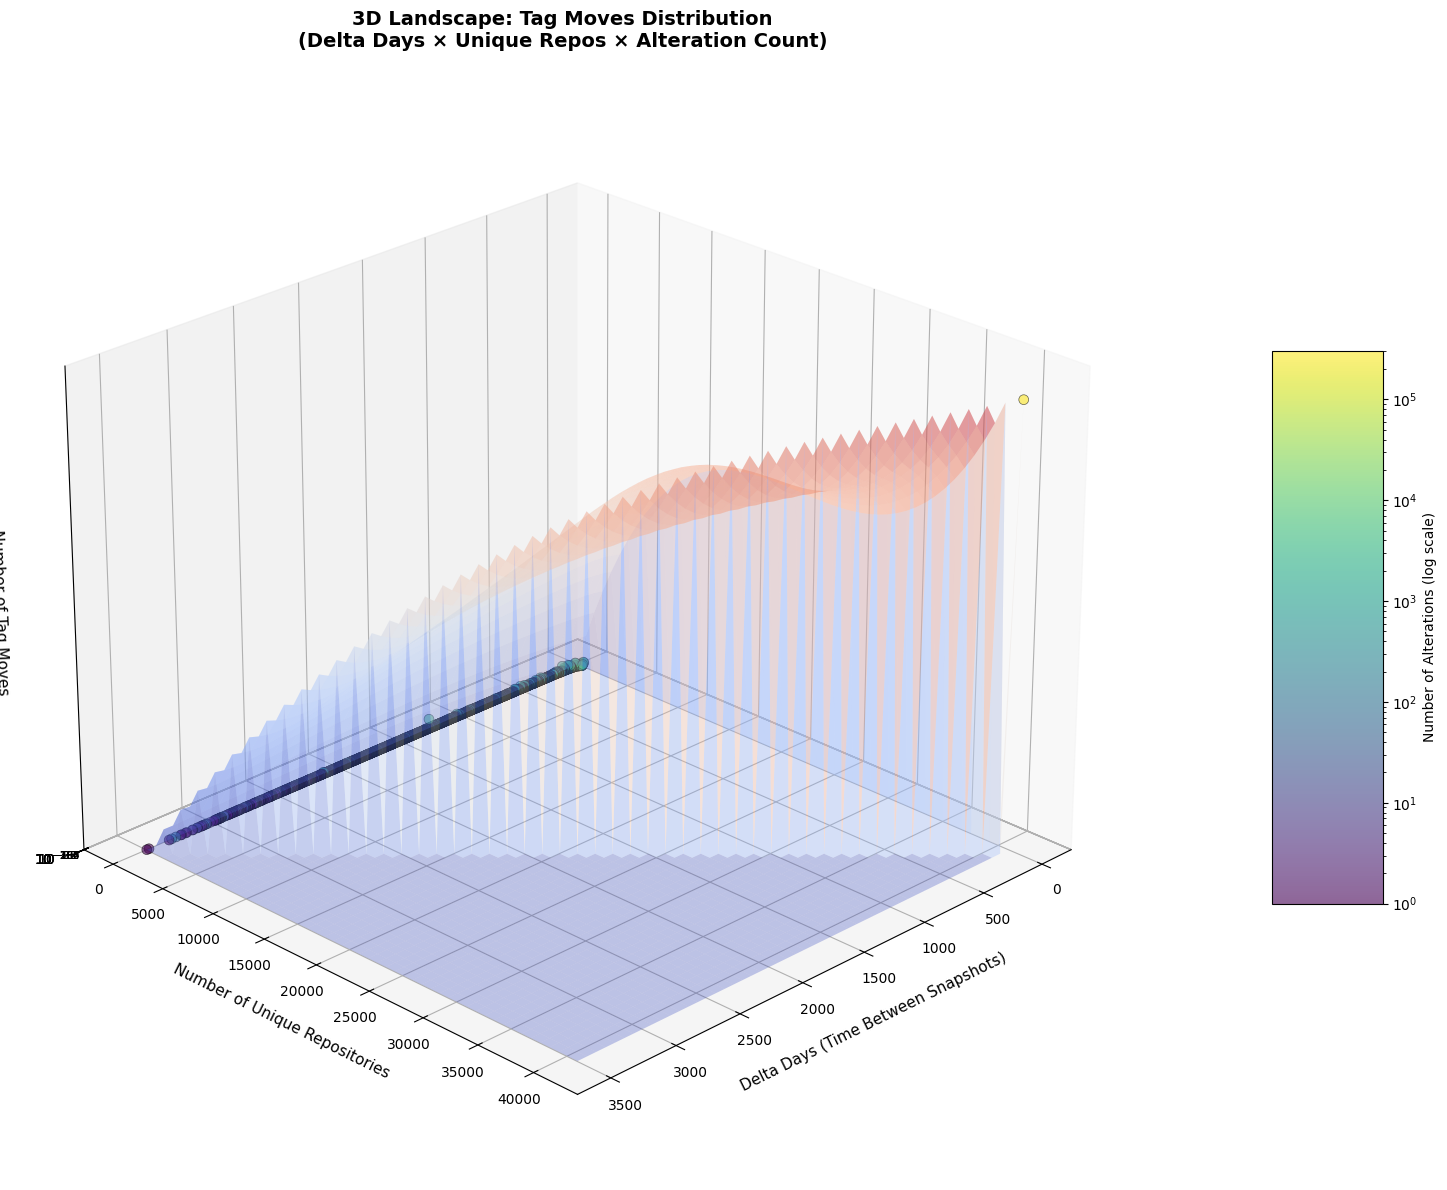

3D plot statistics:
  Delta range: 0 to 3496 days
  Unique repos range: 1 to 40907
  Alteration count range: 1 to 301539
  Total data points plotted: 2306

Peak 'mountains' (highest alteration counts):
  Delta=0d, Repos=40907, Alterations=301539
  Delta=1256d, Repos=8, Alterations=6459
  Delta=140d, Repos=96, Alterations=3948
  Delta=2d, Repos=616, Alterations=3517
  Delta=42d, Repos=261, Alterations=3270


In [35]:
# 3D Surface Plot: Delta Days x Unique Repos x Alteration Count
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Prepare data - aggregate by delta value to get unique repo count and alteration count
# Group by delta value
delta_groups = tag_moves.groupby('delta').agg({
    'origin_url': 'nunique',  # unique repos
    'tag_name': 'count'       # alteration count
}).reset_index()
delta_groups.columns = ['delta', 'unique_repos', 'alteration_count']

# Filter out extreme outliers for better visualization
delta_groups_filtered = delta_groups[delta_groups['delta'] <= 3650]  # Up to 10 years

# Create the scatter plot with color mapping
x = delta_groups_filtered['delta'].values
y = delta_groups_filtered['unique_repos'].values
z = delta_groups_filtered['alteration_count'].values

# Create color map based on alteration count
colors_scatter = plt.cm.viridis(np.log1p(z) / np.log1p(z.max()))
scatter = ax.scatter(x, y, z, c=z, cmap='viridis', s=50, alpha=0.6, 
                     edgecolors='black', linewidth=0.5, norm=plt.matplotlib.colors.LogNorm())

# Create a meshgrid for surface interpolation
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

# Create grid for surface (using broader bins for smoothness)
xi = np.linspace(x_min, x_max, 50)
yi = np.linspace(y_min, y_max, 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate z values on the grid
zi_grid = griddata((x, y), z, (xi_grid, yi_grid), method='cubic', fill_value=0)
zi_grid = np.maximum(zi_grid, 0)  # Remove negative interpolated values

# Plot the surface
surf = ax.plot_surface(xi_grid, yi_grid, zi_grid, cmap='coolwarm', alpha=0.3, 
                       edgecolor='none', antialiased=True)

# Labels and title
ax.set_xlabel('Delta Days (Time Between Snapshots)', fontsize=11, labelpad=10)
ax.set_ylabel('Number of Unique Repositories', fontsize=11, labelpad=10)
ax.set_zlabel('Number of Tag Moves', fontsize=11, labelpad=10)
ax.set_title('3D Landscape: Tag Moves Distribution\n(Delta Days × Unique Repos × Alteration Count)', 
             fontsize=14, fontweight='bold', pad=20)

# Set logarithmic scale for better visualization
ax.set_zscale('log')

# Add colorbar
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5, pad=0.1)
cbar.set_label('Number of Alterations (log scale)', fontsize=10)

# Adjust viewing angle for best perspective
ax.view_init(elev=25, azim=45)

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"3D plot statistics:")
print(f"  Delta range: {x_min:.0f} to {x_max:.0f} days")
print(f"  Unique repos range: {y_min} to {y_max}")
print(f"  Alteration count range: {z.min()} to {z.max()}")
print(f"  Total data points plotted: {len(x)}")
print(f"\nPeak 'mountains' (highest alteration counts):")
top_peaks = delta_groups_filtered.nlargest(5, 'alteration_count')
for idx, row in top_peaks.iterrows():
    print(f"  Delta={row['delta']:.0f}d, Repos={row['unique_repos']}, Alterations={row['alteration_count']}")

## Last. Close Database Connection

In [4]:
conn.close()
print("Database connection closed")

NameError: name 'conn' is not defined